
# CSE440 News Classification Project — PyTorch Version

This notebook is written for the provided train/test CSV files:

- `Training_data_4.csv` or `Training_data_4(2).csv`
- `Test_data.csv` or `Test_data(2).csv`

It follows the assignment requirements:

1. Load and explore the dataset.
2. Create three text versions: no preprocessing, extreme preprocessing, and optimum preprocessing.
3. Train/evaluate:
   - TF-IDF + one ML model
   - TF-IDF + Deep Neural Network
   - Skip-gram + SimpleRNN
   - Skip-gram + GRU
   - Skip-gram + LSTM
   - Skip-gram + Bidirectional SimpleRNN
   - Skip-gram + Bidirectional GRU
   - Skip-gram + Bidirectional LSTM
4. Use validation performance for manual hyperparameter tuning.
5. Report Accuracy, Macro F1, Confusion Matrix, and Classification Report.
6. Keep the test set strictly for final evaluation.

The code uses PyTorch instead of TensorFlow/Keras so the neural-network models can use GPU when CUDA-enabled PyTorch is installed.



## 0. Setup instructions

Run these commands in terminal before opening the notebook.

### Recommended: create and activate a virtual environment

**Windows PowerShell / CMD**

```bash
py -3.12 -m venv .venv
.venv\Scripts\activate
python -m pip install --upgrade pip setuptools wheel
```

**Git Bash**

```bash
py -3.12 -m venv .venv
source .venv/Scripts/activate
python -m pip install --upgrade pip setuptools wheel
```

### Install normal packages

```bash
python -m pip install numpy pandas matplotlib nltk beautifulsoup4 ipython wordcloud scipy scikit-learn gensim notebook
```

### Install PyTorch with NVIDIA GPU support

For your RTX 3050 and NVIDIA driver, start with the CUDA 12.8 PyTorch wheel:

```bash
python -m pip uninstall -y torch torchvision torchaudio
python -m pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128
```

If CUDA still does not work, use the official PyTorch install selector and choose:

- OS: Windows
- Package: Pip
- Language: Python
- Compute Platform: CUDA

Then restart VS Code/Jupyter after installation.

### Verify GPU

```python
import torch

print(torch.__version__)
print(torch.backends.cuda.is_built())
print(torch.version.cuda)
print(torch.cuda.is_available())

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))
```

You want `torch.cuda.is_available()` to print `True`.


## Requirement alignment checklist

This notebook is organized to match the project instructions:

| Requirement | Where it is handled |
|---|---|
| Load separate train/test CSV files | Section 1 |
| Use training set for training and validation | Sections 4–11 |
| Keep test set for final evaluation only | Section 12 |
| Extensive EDA | Section 2 |
| Three preprocessing versions | Section 3 |
| TF-IDF representation | Sections 6–7 |
| Skip-gram representation | Sections 8–10 |
| At least one ML model | Section 6 |
| Deep Neural Network with 4+ layers and 128+ first hidden neurons | Section 7 |
| SimpleRNN, GRU, LSTM, BiRNN, BiGRU, BiLSTM | Sections 9–10 |
| Manual hyperparameter tuning using validation macro F1 | Sections 6, 7, 10, 11 |
| Accuracy, macro F1, classification report, confusion matrix | Sections 5 and 12 |
| Tabular and visual comparison | Sections 11 and 13 |
| Best/worst model and preprocessing comparison | Section 13 |

The test set is loaded only to verify file availability and column compatibility before final evaluation. Hyperparameters and preprocessing decisions are selected using the training/validation split only.


In [1]:
import sys
import torch

print("Python:", sys.executable)
print("Torch:", torch.__version__)
print("CUDA built:", torch.backends.cuda.is_built())
print("Torch CUDA:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Python: D:\Programming\CSE440\NLP-About-News\.venv\Scripts\python.exe
Torch: 2.11.0+cu128
CUDA built: True
Torch CUDA: 12.8
CUDA available: True
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


In [2]:
import os
import re
import html
import json
import pickle
import random
import warnings
import hashlib
import time
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nltk
import torch

from pathlib import Path
from bs4 import BeautifulSoup
from collections import Counter
from IPython.display import display
from wordcloud import WordCloud
from gensim.models import Word2Vec

from scipy.sparse import save_npz, load_npz
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer, ENGLISH_STOP_WORDS
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import TruncatedSVD

from nltk.stem import PorterStemmer
from torch import nn
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 300)
pd.set_option("display.max_columns", 100)

try:
    nltk.data.find("tokenizers/punkt")
except LookupError:
    nltk.download("punkt", quiet=True)

SEED = 42
TARGET_COLUMN = "News Topic"
RAW_TEXT_COLUMN = "News Headline"
TEXT_COLUMN = "text"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

try:
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True
except Exception:
    pass

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = torch.cuda.is_available()

print("PyTorch version:", torch.__version__)
print("CUDA built:", torch.backends.cuda.is_built())
print("Torch CUDA version:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())
print("Using device:", device)
print("Mixed precision AMP:", USE_AMP)

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

BASE_DIR = Path("project_cache_pytorch")
PREPROCESSED_DIR = BASE_DIR / "preprocessed"
SPLIT_DIR = BASE_DIR / "splits"
TFIDF_DIR = BASE_DIR / "tfidf"
SKIPGRAM_DIR = BASE_DIR / "skipgram"
CHECKPOINT_DIR = BASE_DIR / "checkpoints"
HISTORY_DIR = BASE_DIR / "history"
FIGURE_DIR = Path("figures")
LOG_DIR = Path("logs")

for folder in [
    PREPROCESSED_DIR,
    SPLIT_DIR,
    TFIDF_DIR,
    SKIPGRAM_DIR,
    CHECKPOINT_DIR,
    HISTORY_DIR,
    FIGURE_DIR,
    LOG_DIR
]:
    folder.mkdir(parents=True, exist_ok=True)

FORCE_REBUILD_PREPROCESSED = False
FORCE_NEW_SPLIT = False
FORCE_REBUILD_FEATURES = False
FORCE_REBUILD_SKIPGRAM = False
FORCE_RETRAIN = False

RUN_TFIDF_ML = True
RUN_TFIDF_DNN = True
RUN_SKIPGRAM_NN = True

INTENSIVE_TUNING = True
RUN_NAIVE_BAYES_TFIDF = True
RUN_RANDOM_FOREST_TFIDF = False
FINAL_TEST_ALL_VALIDATION_WINNERS = True
SAVE_TEST_PREDICTIONS = True

DEBUG_SMALL_RUN = False
DEBUG_TRAIN_ROWS = 15000
DEBUG_TEST_ROWS = 3000

print("Intensive tuning:", INTENSIVE_TUNING)
print("Debug small run:", DEBUG_SMALL_RUN)


PyTorch version: 2.11.0+cu128
CUDA built: True
Torch CUDA version: 12.8
CUDA available: True
Using device: cuda
Mixed precision AMP: True
GPU name: NVIDIA GeForce RTX 3050 Laptop GPU
Intensive tuning: True
Debug small run: False


## 1. Load the provided training and testing datasets

In [3]:
def resolve_file_path(possible_filenames):
    if isinstance(possible_filenames, str):
        possible_filenames = [possible_filenames]

    search_dirs = [
        Path.cwd(),
        Path.cwd() / "data",
        Path("/mnt/data")
    ]

    candidates = []
    for filename in possible_filenames:
        path = Path(filename)
        candidates.append(path)
        for directory in search_dirs:
            candidates.append(directory / filename)

    for path in candidates:
        if path.exists():
            return path

    csv_files = sorted(Path.cwd().glob("*.csv")) + sorted((Path.cwd() / "data").glob("*.csv")) if (Path.cwd() / "data").exists() else sorted(Path.cwd().glob("*.csv"))
    csv_files += sorted(Path("/mnt/data").glob("*.csv"))

    print("CSV files found:")
    for file in csv_files:
        print(" -", file)

    raise FileNotFoundError(f"Could not find any of these files: {possible_filenames}")

TRAIN_PATH = resolve_file_path([
    "Training_data_4.csv",
    "Training_data_4(2).csv",
    "training_data_4.csv",
    "train.csv"
])

TEST_PATH = resolve_file_path([
    "Test_data.csv",
    "Test_data(2).csv",
    "test_data.csv",
    "test.csv"
])

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print("Training file:", TRAIN_PATH)
print("Testing file:", TEST_PATH)
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

required_columns = [RAW_TEXT_COLUMN, TARGET_COLUMN]
for column in required_columns:
    if column not in train_df.columns:
        raise ValueError(f"Missing column in train data: {column}")
    if column not in test_df.columns:
        raise ValueError(f"Missing column in test data: {column}")

if DEBUG_SMALL_RUN:
    train_df = train_df.sample(n=min(DEBUG_TRAIN_ROWS, len(train_df)), random_state=SEED).reset_index(drop=True)
    test_df = test_df.sample(n=min(DEBUG_TEST_ROWS, len(test_df)), random_state=SEED).reset_index(drop=True)
    print("DEBUG mode enabled.")
    print("Debug train shape:", train_df.shape)
    print("Debug test shape:", test_df.shape)

print("Training sample")
display(train_df.head())
print("Test set is held out. Head rows are not displayed here to avoid using it for decisions.")


Training file: Training_data_4.csv
Testing file: Test_data.csv
Train shape: (104763, 2)
Test shape: (12000, 2)
Training sample


,News Headline,News Topic
0,<html> <body> News Headlines:\r\n <br> <b> Huge boost to Darfur aid effort The World Food Programme is starting to airlift almost 100 more tons of food a day to Sudan's troubled Darfur region. </b> \r\n <br> <br>,World News
1,"<html> <body> News Headlines:\r\n <br> <b> Microsoft Revises Anti-Spam Standard (Reuters) Reuters - Microsoft Corp. on Monday\said it had revised its proposal to weed out ""spam"" e-mail to\win over skeptical Internet engineers who have been reluctant\to adopt technology owned by the dominant sof...",Science and Technology
2,"<html> <body> News Headlines:\r\n <br> <b> Gordon Cooper, 1 of 1st astronauts VENTURA, Calif. - Gordon Cooper, who as one of the original Mercury astronauts was a pioneer in human space exploration, has died. </b> \r\n <br> <br>",Science and Technology
3,<html> <body> News Headlines:\r\n <br> <b> U.S. Trade Deficit Swells to Record #36;55.5B (AP) AP - America's trade deficit swelled to an all-time high of #36;55.5 billion in October as imports #151; including those from China #151; surged to the loftiest levels on record. Skyrocketing crude-...,Business
4,"<html> <body> News Headlines:\r\n <br> <b> Nonunion firms hit ironworkers with suit Six New England steel-working firms have filed an antitrust lawsuit against one of Boston's most powerful and politically connected unions, alleging that the labor group has conspired to shut out nonunion compani...",Business


Test set is held out. Head rows are not displayed here to avoid using it for decisions.


## 2. Exploratory Data Analysis

In [4]:

print("Training information")
display(train_df.info())

print("\nTraining missing values")
display(train_df.isna().sum())

print("\nTraining duplicate rows:", train_df.duplicated().sum())

print("\nTraining class distribution")
display(train_df[TARGET_COLUMN].value_counts().to_frame("count"))

print("\nHeld-out test set status")
print("The test file is loaded only to confirm availability and column compatibility.")
print("Test shape:", test_df.shape)
print("Test labels and test performance are not used for preprocessing decisions or hyperparameter tuning.")


Training information
<class 'pandas.DataFrame'>
RangeIndex: 104763 entries, 0 to 104762
Data columns (total 2 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   News Headline  104763 non-null  str  
 1   News Topic     104763 non-null  str  
dtypes: str(2)
memory usage: 1.6 MB


None


Training missing values


News Headline    0
News Topic       0
dtype: int64


Training duplicate rows: 31208

Training class distribution


,count
News Topic,
Science and Technology,36428
Sports,34178
Business,18563
World News,15594



Held-out test set status
The test file is loaded only to confirm availability and column compatibility.
Test shape: (12000, 2)
Test labels and test performance are not used for preprocessing decisions or hyperparameter tuning.


### Leakage and baseline sanity checks

These checks help explain unusually high accuracy and verify that the test set is not leaking into training.


In [5]:

def normalize_for_leakage_check(text):
    text = "" if pd.isna(text) else str(text)
    text = html.unescape(text)
    text = BeautifulSoup(text, "html.parser").get_text(" ")
    text = re.sub(r"\s+", " ", text).lower().strip()
    return text

train_headlines_normalized = train_df[RAW_TEXT_COLUMN].apply(normalize_for_leakage_check)

print("Training duplicate normalized headlines:", train_headlines_normalized.duplicated().sum())

if train_headlines_normalized.duplicated().sum() > 0:
    print("Sample duplicate training headlines:")
    display(train_df.loc[train_headlines_normalized.duplicated(keep=False), [RAW_TEXT_COLUMN, TARGET_COLUMN]].head(10))

def label_inside_headline_rate(df):
    checks = []
    for _, row in df[[RAW_TEXT_COLUMN, TARGET_COLUMN]].iterrows():
        text = normalize_for_leakage_check(row[RAW_TEXT_COLUMN])
        label = normalize_for_leakage_check(row[TARGET_COLUMN])
        checks.append(label in text if label else False)
    return np.mean(checks)

print("Training rows where exact label text appears inside headline:", round(label_inside_headline_rate(train_df), 4))

majority_class_train = train_df[TARGET_COLUMN].value_counts().idxmax()
majority_train_rate = (train_df[TARGET_COLUMN] == majority_class_train).mean()
print("Training majority class:", majority_class_train)
print("Training majority-class proportion:", round(majority_train_rate, 5))

print("\nNote: train-test overlap and test-set baseline are reported in the final evaluation section only.")


Training duplicate normalized headlines: 31270
Sample duplicate training headlines:


,News Headline,News Topic
1,"<html> <body> News Headlines:\r\n <br> <b> Microsoft Revises Anti-Spam Standard (Reuters) Reuters - Microsoft Corp. on Monday\said it had revised its proposal to weed out ""spam"" e-mail to\win over skeptical Internet engineers who have been reluctant\to adopt technology owned by the dominant sof...",Science and Technology
2,"<html> <body> News Headlines:\r\n <br> <b> Gordon Cooper, 1 of 1st astronauts VENTURA, Calif. - Gordon Cooper, who as one of the original Mercury astronauts was a pioneer in human space exploration, has died. </b> \r\n <br> <br>",Science and Technology
13,<html> <body> News Headlines:\r\n <br> <b> Red Sox Nation thrives in California Standing in his rhinestone-studded Elvis suit with a Massachusetts license plate dangling from his neck and a Boston Red Sox hat on </b> \r\n <br> <br>,Sports
17,"<html> <body> News Headlines:\r\n <br> <b> Ivy product climbs in NFL If Lehman Brothers had come through for Eric Johnson, the Seahawks would be breathing easier this afternoon. </b> \r\n <br> <br>",Sports
20,"<html> <body> News Headlines:\r\n <br> <b> California Cities and Counties Sue Microsoft By PAUL ELIAS SAN FRANCISCO (AP) -- Several California cities and counties, including San Francisco and Los Angeles, sued Microsoft Corp. (MSFT) on Friday, accusing the software giant of illegally charging...",Science and Technology
21,"<html> <body> News Headlines:\r\n <br> <b> Motorola to Build Cell Phones Into Ski Jackets CHICAGO (Reuters) - Motorola Inc. &lt;A HREF=""http://www.reuters.co.uk/financeQuoteLookup.jhtml?ticker=MOT.N qtype=sym infotype=info qcat=news""&gt;MOT.N&lt;/A&gt; said it will unveil plans this week for a...",Science and Technology
22,<html> <body> News Headlines:\r\n <br> <b> Why The Open-Source Model Can Work In India An Indian Institute of Technology professor--and open-source evangelist--discusses the role of Linux and open source in India. By Larry Greenemeier. </b> \r\n <br> <br>,Science and Technology
27,"<html> <body> News Headlines:\r\n <br> <b> A breath of fresh heir at BU Incoming Boston University freshman Chris Bourque recently filled out the Terriers' standard player form that is kept on file at the school's sports information office. quot;It's all the usual stuff -- date of birth, height...",Sports
28,"<html> <body> News Headlines:\r\n <br> <b> Mercyhurst knows drill Mercyhurst coach Rick Gotkin believes in Atlantic Hockey. Four years ago when the Metro Atlantic Athletic Conference was born, Mercyhurst was simply the cream of the crop. </b> \r\n <br> <br>",Sports
29,"<html> <body> News Headlines:\r\n <br> <b> Cracking start to quest, but no sign of Holy Grail TWO veteran code-breakers from Yorkshire have received a worldwide response to their request for solutions to an enigmatic message on a monument in Staffordshire reputed to say where the Holy Grail is h...",Science and Technology


Training rows where exact label text appears inside headline: 0.0336
Training majority class: Science and Technology
Training majority-class proportion: 0.34772

Note: train-test overlap and test-set baseline are reported in the final evaluation section only.


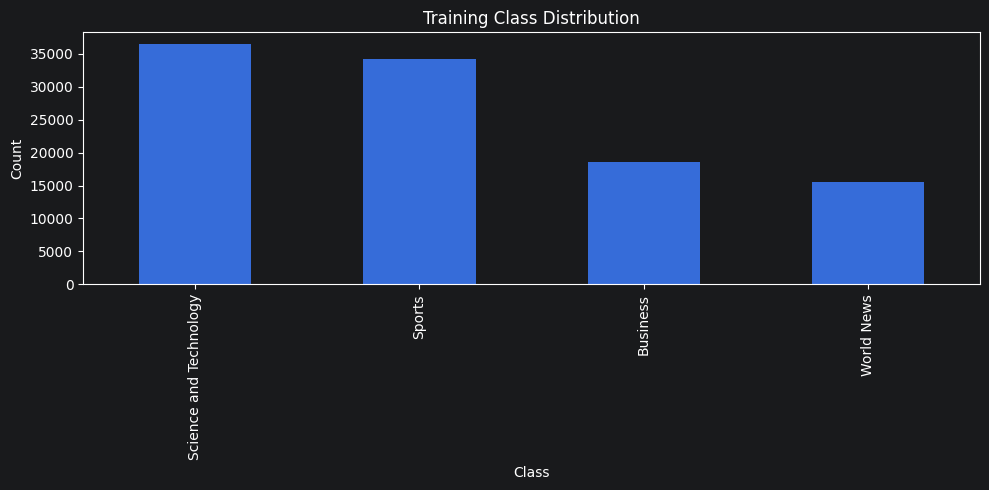

In [6]:

plt.figure(figsize=(10, 5))
train_df[TARGET_COLUMN].value_counts().plot(kind="bar", title="Training Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


,clean_preview_text,News Topic,char_len,word_len
0,News Headlines: Huge boost to Darfur aid effort The World Food Programme is starting to airlift almost 100 more tons of food a day to Sudan's troubled Darfur region.,World News,165,29
1,"News Headlines: Microsoft Revises Anti-Spam Standard (Reuters) Reuters - Microsoft Corp. on Monday\said it had revised its proposal to weed out ""spam"" e-mail to\win over skeptical Internet engineers who have been reluctant\to adopt technology owned by the dominant software company.",Science and Technology,282,40
2,"News Headlines: Gordon Cooper, 1 of 1st astronauts VENTURA, Calif. - Gordon Cooper, who as one of the original Mercury astronauts was a pioneer in human space exploration, has died.",Science and Technology,181,30
3,News Headlines: U.S. Trade Deficit Swells to Record #36;55.5B (AP) AP - America's trade deficit swelled to an all-time high of #36;55.5 billion in October as imports #151; including those from China #151; surged to the loftiest levels on record. Skyrocketing crude-oil prices also contributed to ...,Business,318,50
4,"News Headlines: Nonunion firms hit ironworkers with suit Six New England steel-working firms have filed an antitrust lawsuit against one of Boston's most powerful and politically connected unions, alleging that the labor group has conspired to shut out nonunion companies from major construction ...",Business,319,47


Text length summary


,char_len,word_len
count,104763.000000,104763.000000
mean,247.072535,39.621374
std,62.420338,10.359664
min,53.000000,9.000000
25%,209.000000,33.000000
50%,244.000000,39.000000
75%,277.000000,45.000000
max,992.000000,173.000000


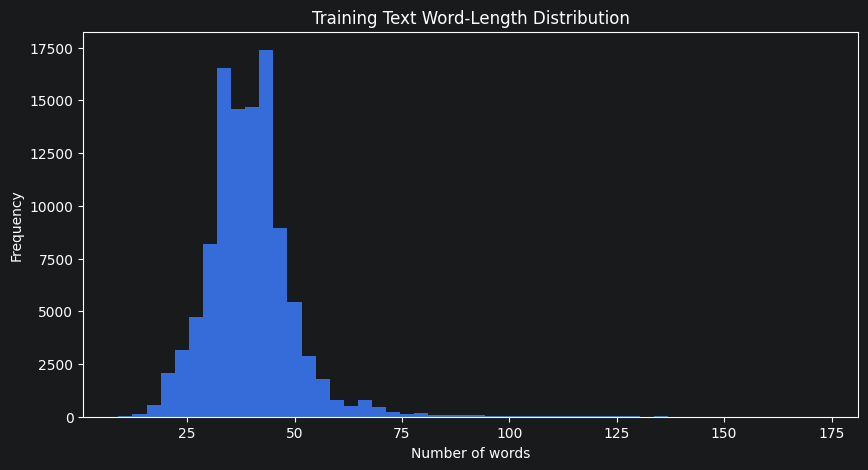

Average word count by class


,count,mean,median,min,max
News Topic,,,,,
World News,15594,40.877966,41.0,13,147
Sports,34178,39.695828,39.0,12,144
Business,18563,39.420729,39.0,9,129
Science and Technology,36428,39.115845,38.0,10,173


In [7]:

def quick_html_to_text(text):
    text = "" if pd.isna(text) else str(text)
    text = html.unescape(text)
    text = BeautifulSoup(text, "html.parser").get_text(" ")
    text = re.sub(r"\s+", " ", text).strip()
    return text

eda_train = train_df.copy()
eda_train["clean_preview_text"] = eda_train[RAW_TEXT_COLUMN].apply(quick_html_to_text)
eda_train["char_len"] = eda_train["clean_preview_text"].str.len()
eda_train["word_len"] = eda_train["clean_preview_text"].str.split().apply(len)

display(eda_train[["clean_preview_text", TARGET_COLUMN, "char_len", "word_len"]].head())

print("Text length summary")
display(eda_train[["char_len", "word_len"]].describe())

plt.figure(figsize=(10, 5))
plt.hist(eda_train["word_len"], bins=50)
plt.title("Training Text Word-Length Distribution")
plt.xlabel("Number of words")
plt.ylabel("Frequency")
plt.show()

print("Average word count by class")
display(eda_train.groupby(TARGET_COLUMN)["word_len"].agg(["count", "mean", "median", "min", "max"]).sort_values("mean", ascending=False))


In [8]:

def regex_tokens(text):
    return re.findall(r"[a-zA-Z][a-zA-Z0-9-]*|\d+(?:\.\d+)?", str(text).lower())

all_tokens = []
class_tokens = {}

for label, group in eda_train.groupby(TARGET_COLUMN):
    tokens = []
    for text in group["clean_preview_text"].head(10000):
        tokens.extend(regex_tokens(text))
    class_tokens[label] = tokens
    all_tokens.extend(tokens)

overall_counter = Counter(all_tokens)
print("Top 30 overall tokens before preprocessing")
display(pd.DataFrame(overall_counter.most_common(30), columns=["token", "count"]))

for label, tokens in class_tokens.items():
    print(f"\nTop 20 tokens for class: {label}")
    display(pd.DataFrame(Counter(tokens).most_common(20), columns=["token", "count"]))


Top 30 overall tokens before preprocessing


,token,count
0,the,68422
1,news,41122
2,headlines,40033
3,to,39904
4,a,36344
5,of,32799
6,in,32136
7,and,23220
8,s,20827
9,on,19134



Top 20 tokens for class: Business


,token,count
0,the,14951
1,news,10391
2,headlines,10006
3,to,9982
4,a,8360
5,of,7473
6,in,7463
7,s,5718
8,and,5686
9,on,5554



Top 20 tokens for class: Science and Technology


,token,count
0,the,16061
1,to,10547
2,news,10368
3,headlines,10008
4,a,9011
5,of,8814
6,and,6237
7,in,6001
8,s,4536
9,for,4310



Top 20 tokens for class: Sports


,token,count
0,the,21099
1,news,10126
2,headlines,10018
3,to,9088
4,a,8748
5,in,7989
6,of,6809
7,and,5362
8,39,4878
9,s,4761



Top 20 tokens for class: World News


,token,count
0,the,16311
1,in,10683
2,to,10287
3,news,10237
4,a,10225
5,headlines,10001
6,of,9703
7,and,5935
8,s,5812
9,on,5474


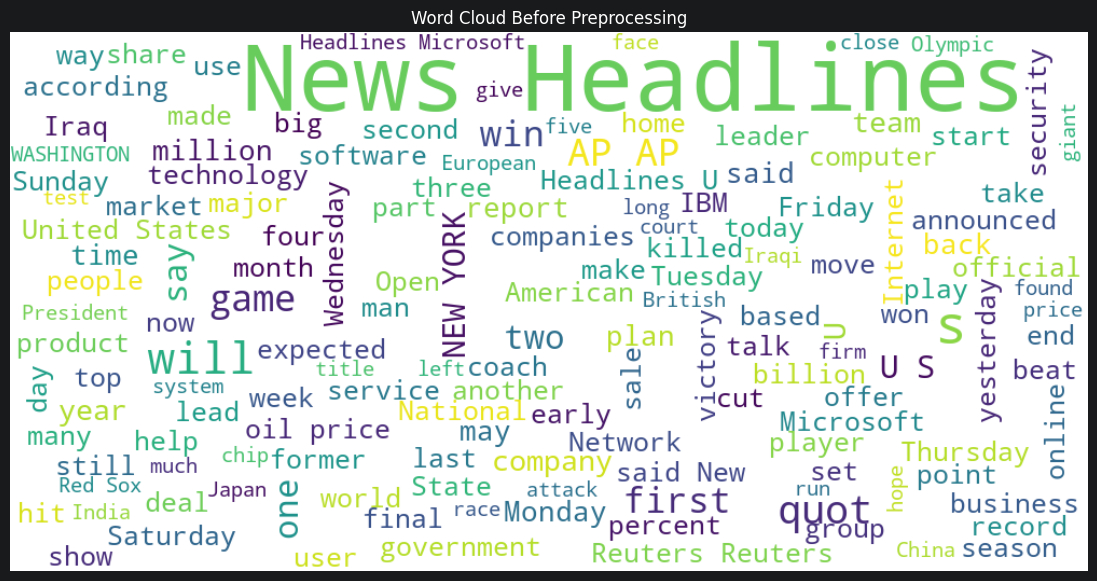

In [9]:

sample_text_for_wordcloud = " ".join(eda_train["clean_preview_text"].sample(min(8000, len(eda_train)), random_state=SEED))

wordcloud = WordCloud(width=1000, height=500, background_color="white", max_words=150).generate(sample_text_for_wordcloud)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud Before Preprocessing")
plt.show()



### EDA decision for preprocessing

The raw text contains HTML tags and repeated boilerplate such as `News Headlines`. The extreme version removes aggressively and stems words. The optimum version removes HTML/boilerplate/noise but does not stem, because stemming can damage important news-category signals such as company names, sports teams, places, and technology terms.


## 3. Preprocessing: none, extreme, and optimum

In [10]:
stemmer = PorterStemmer()

STOPWORDS = set(ENGLISH_STOP_WORDS)
DOMAIN_NOISE = {
    "html", "body", "br", "b", "news", "headline", "headlines",
    "reuters", "ap", "afp", "said", "says", "say"
}

def strip_html(text):
    text = "" if pd.isna(text) else str(text)
    text = html.unescape(text)
    text = BeautifulSoup(text, "html.parser").get_text(" ")
    text = re.sub(r"News\s+Headlines\s*: ?", " ", text, flags=re.IGNORECASE)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def normalize_abbreviations(text):
    text = re.sub(r"\bu\.s\.\b", "us", text, flags=re.IGNORECASE)
    text = re.sub(r"\bu\.k\.\b", "uk", text, flags=re.IGNORECASE)
    text = re.sub(r"\be\.u\.\b", "eu", text, flags=re.IGNORECASE)
    text = re.sub(r"\bu\.n\.\b", "un", text, flags=re.IGNORECASE)
    return text

def tokenize_for_project(text):
    return re.findall(r"[a-zA-Z][a-zA-Z0-9-]*|\d+(?:\.\d+)?", str(text).lower())

def preprocess_none(text):
    return "" if pd.isna(text) else str(text)

def preprocess_extreme(text):
    text = strip_html(text)
    text = normalize_abbreviations(text)
    text = text.lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"\S+@\S+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    tokens = text.split()
    tokens = [
        stemmer.stem(token)
        for token in tokens
        if token not in STOPWORDS
        and token not in DOMAIN_NOISE
        and len(token) > 2
    ]
    return " ".join(tokens)

def preprocess_optimum(text):
    text = strip_html(text)
    text = normalize_abbreviations(text)
    text = text.lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"\S+@\S+", " ", text)
    text = re.sub(r"&[a-z]+;", " ", text)
    text = re.sub(r"[^a-z0-9\-\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    tokens = tokenize_for_project(text)
    tokens = [
        token
        for token in tokens
        if token not in DOMAIN_NOISE
        and len(token) > 1
        and len(token) <= 30
    ]
    return " ".join(tokens)

PREPROCESSORS = {
    "none": preprocess_none,
    "extreme": preprocess_extreme,
    "optimum": preprocess_optimum
}

def cache_name_for_dataframe(df, split_name, preprocess_name):
    columns_for_hash = [RAW_TEXT_COLUMN, TARGET_COLUMN]
    content_hash = hashlib.md5(
        pd.util.hash_pandas_object(df[columns_for_hash].astype(str), index=True).values.tobytes()
    ).hexdigest()[:12]
    preprocessor_hash = hashlib.md5(PREPROCESSORS[preprocess_name].__code__.co_code).hexdigest()[:8]
    raw_key = f"{split_name}_{preprocess_name}_{len(df)}_{content_hash}_{preprocessor_hash}"
    return PREPROCESSED_DIR / f"{raw_key}.csv"

def build_or_load_preprocessed(df, split_name, preprocess_name, force=False):
    cache_path = cache_name_for_dataframe(df, split_name, preprocess_name)

    if cache_path.exists() and not force:
        loaded = pd.read_csv(cache_path)
        loaded[TEXT_COLUMN] = loaded[TEXT_COLUMN].fillna("")
        return loaded

    out = df.copy()
    out[TEXT_COLUMN] = out[RAW_TEXT_COLUMN].apply(PREPROCESSORS[preprocess_name])
    out[TEXT_COLUMN] = out[TEXT_COLUMN].fillna("")
    out.to_csv(cache_path, index=False)
    return out

preprocessed_train = {}
preprocessed_test = {}

for preprocess_name in PREPROCESSORS:
    print("Preparing:", preprocess_name)
    preprocessed_train[preprocess_name] = build_or_load_preprocessed(
        train_df, "train", preprocess_name, FORCE_REBUILD_PREPROCESSED
    )
    preprocessed_test[preprocess_name] = build_or_load_preprocessed(
        test_df, "test", preprocess_name, FORCE_REBUILD_PREPROCESSED
    )

print("Test preprocessing was prepared with fixed functions only. No vectorizer, Word2Vec model, ML model, or neural model is fitted on test data.")

for preprocess_name in PREPROCESSORS:
    print("\nPreprocessing:", preprocess_name)
    display(preprocessed_train[preprocess_name][[RAW_TEXT_COLUMN, TEXT_COLUMN, TARGET_COLUMN]].head(3))


Preparing: none
Preparing: extreme
Preparing: optimum
Test preprocessing was prepared with fixed functions only. No vectorizer, Word2Vec model, ML model, or neural model is fitted on test data.

Preprocessing: none


,News Headline,text,News Topic
0,<html> <body> News Headlines:\r\n <br> <b> Huge boost to Darfur aid effort The World Food Programme is starting to airlift almost 100 more tons of food a day to Sudan's troubled Darfur region. </b> \r\n <br> <br>,<html> <body> News Headlines:\r\n <br> <b> Huge boost to Darfur aid effort The World Food Programme is starting to airlift almost 100 more tons of food a day to Sudan's troubled Darfur region. </b> \r\n <br> <br>,World News
1,"<html> <body> News Headlines:\r\n <br> <b> Microsoft Revises Anti-Spam Standard (Reuters) Reuters - Microsoft Corp. on Monday\said it had revised its proposal to weed out ""spam"" e-mail to\win over skeptical Internet engineers who have been reluctant\to adopt technology owned by the dominant sof...","<html> <body> News Headlines:\r\n <br> <b> Microsoft Revises Anti-Spam Standard (Reuters) Reuters - Microsoft Corp. on Monday\said it had revised its proposal to weed out ""spam"" e-mail to\win over skeptical Internet engineers who have been reluctant\to adopt technology owned by the dominant sof...",Science and Technology
2,"<html> <body> News Headlines:\r\n <br> <b> Gordon Cooper, 1 of 1st astronauts VENTURA, Calif. - Gordon Cooper, who as one of the original Mercury astronauts was a pioneer in human space exploration, has died. </b> \r\n <br> <br>","<html> <body> News Headlines:\r\n <br> <b> Gordon Cooper, 1 of 1st astronauts VENTURA, Calif. - Gordon Cooper, who as one of the original Mercury astronauts was a pioneer in human space exploration, has died. </b> \r\n <br> <br>",Science and Technology



Preprocessing: extreme


,News Headline,text,News Topic
0,<html> <body> News Headlines:\r\n <br> <b> Huge boost to Darfur aid effort The World Food Programme is starting to airlift almost 100 more tons of food a day to Sudan's troubled Darfur region. </b> \r\n <br> <br>,huge boost darfur aid effort world food programm start airlift ton food day sudan troubl darfur region,World News
1,"<html> <body> News Headlines:\r\n <br> <b> Microsoft Revises Anti-Spam Standard (Reuters) Reuters - Microsoft Corp. on Monday\said it had revised its proposal to weed out ""spam"" e-mail to\win over skeptical Internet engineers who have been reluctant\to adopt technology owned by the dominant sof...",microsoft revis anti spam standard microsoft corp monday revis propos weed spam mail win skeptic internet engin reluct adopt technolog own domin softwar compani,Science and Technology
2,"<html> <body> News Headlines:\r\n <br> <b> Gordon Cooper, 1 of 1st astronauts VENTURA, Calif. - Gordon Cooper, who as one of the original Mercury astronauts was a pioneer in human space exploration, has died. </b> \r\n <br> <br>",gordon cooper astronaut ventura calif gordon cooper origin mercuri astronaut pioneer human space explor die,Science and Technology



Preprocessing: optimum


,News Headline,text,News Topic
0,<html> <body> News Headlines:\r\n <br> <b> Huge boost to Darfur aid effort The World Food Programme is starting to airlift almost 100 more tons of food a day to Sudan's troubled Darfur region. </b> \r\n <br> <br>,huge boost to darfur aid effort the world food programme is starting to airlift almost 100 more tons of food day to sudan troubled darfur region,World News
1,"<html> <body> News Headlines:\r\n <br> <b> Microsoft Revises Anti-Spam Standard (Reuters) Reuters - Microsoft Corp. on Monday\said it had revised its proposal to weed out ""spam"" e-mail to\win over skeptical Internet engineers who have been reluctant\to adopt technology owned by the dominant sof...",microsoft revises anti-spam standard microsoft corp on monday it had revised its proposal to weed out spam e-mail to win over skeptical internet engineers who have been reluctant to adopt technology owned by the dominant software company,Science and Technology
2,"<html> <body> News Headlines:\r\n <br> <b> Gordon Cooper, 1 of 1st astronauts VENTURA, Calif. - Gordon Cooper, who as one of the original Mercury astronauts was a pioneer in human space exploration, has died. </b> \r\n <br> <br>",gordon cooper of st astronauts ventura calif gordon cooper who as one of the original mercury astronauts was pioneer in human space exploration has died,Science and Technology



Length summary for none


count    104763.000000
mean         46.677701
std          10.393169
min          17.000000
25%          40.000000
50%          46.000000
75%          52.000000
max         180.000000
Name: word_len, dtype: float64

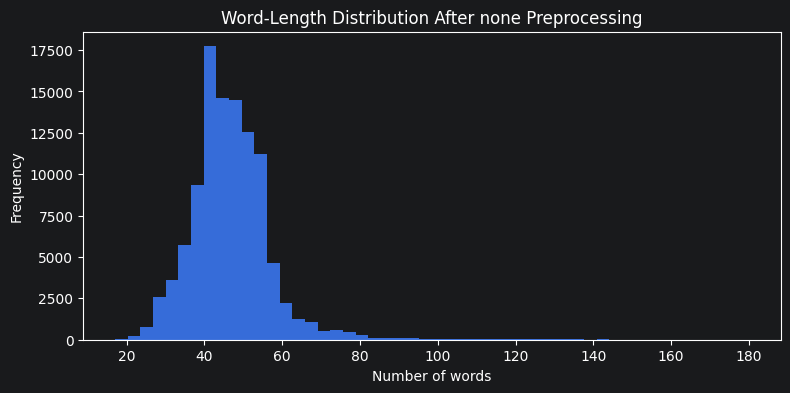


Length summary for extreme


count    104763.000000
mean         22.458874
std           5.947205
min           5.000000
25%          19.000000
50%          22.000000
75%          26.000000
max          86.000000
Name: word_len, dtype: float64

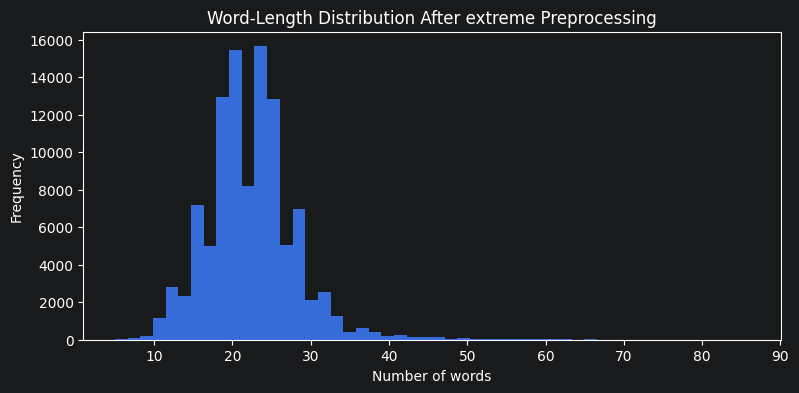


Length summary for optimum


count    104763.000000
mean         35.836994
std           9.907961
min           6.000000
25%          30.000000
50%          35.000000
75%          41.000000
max         161.000000
Name: word_len, dtype: float64

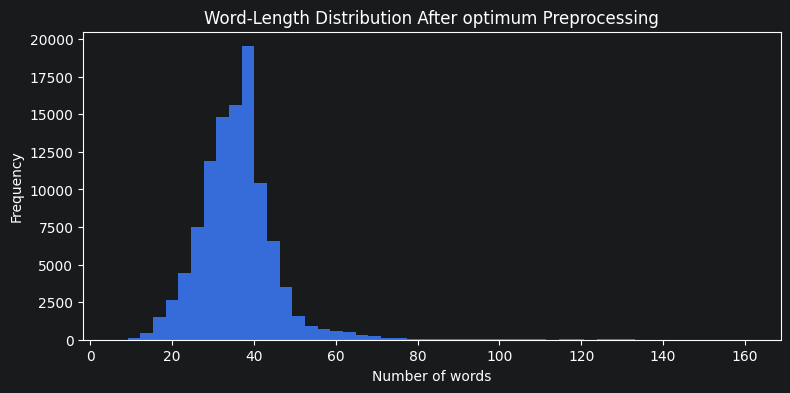

In [11]:

for preprocess_name in PREPROCESSORS:
    temp = preprocessed_train[preprocess_name].copy()
    temp["word_len"] = temp[TEXT_COLUMN].str.split().apply(len)

    print(f"\nLength summary for {preprocess_name}")
    display(temp["word_len"].describe())

    plt.figure(figsize=(9, 4))
    plt.hist(temp["word_len"], bins=50)
    plt.title(f"Word-Length Distribution After {preprocess_name} Preprocessing")
    plt.xlabel("Number of words")
    plt.ylabel("Frequency")
    plt.show()


## 4. Label encoding and validation split

In [12]:

label_encoder = LabelEncoder()
y_train_full = label_encoder.fit_transform(train_df[TARGET_COLUMN])
y_test = label_encoder.transform(test_df[TARGET_COLUMN])
class_names = list(label_encoder.classes_)
num_classes = len(class_names)

print("Classes:", class_names)

split_hash = hashlib.md5(
    pd.util.hash_pandas_object(train_df[[RAW_TEXT_COLUMN, TARGET_COLUMN]].astype(str), index=True).values.tobytes()
).hexdigest()[:12]
split_cache_path = SPLIT_DIR / f"train_validation_indices_{split_hash}_seed{SEED}.pkl"

if split_cache_path.exists() and not FORCE_NEW_SPLIT:
    with open(split_cache_path, "rb") as f:
        split_data = pickle.load(f)
    train_idx = split_data["train_idx"]
    val_idx = split_data["val_idx"]
else:
    train_idx, val_idx = train_test_split(
        np.arange(len(train_df)),
        test_size=0.15,
        random_state=SEED,
        stratify=y_train_full
    )
    with open(split_cache_path, "wb") as f:
        pickle.dump({"train_idx": train_idx, "val_idx": val_idx}, f)

y_train_core = y_train_full[train_idx]
y_val = y_train_full[val_idx]

print("Training rows used for model fitting:", len(train_idx))
print("Validation rows used for tuning:", len(val_idx))
print("Final test rows:", len(y_test))

print("\nValidation class distribution")
display(pd.Series(y_val).map(dict(enumerate(class_names))).value_counts().to_frame("count"))


Classes: ['Business', 'Science and Technology', 'Sports', 'World News']
Training rows used for model fitting: 89048
Validation rows used for tuning: 15715
Final test rows: 12000

Validation class distribution


,count
Science and Technology,5464
Sports,5127
Business,2785
World News,2339


## 5. Shared evaluation and logging functions

In [13]:
EXPERIMENT_LOG = []
BEST_ARTIFACTS = {}


def now_string():
    return time.strftime("%Y-%m-%d %H:%M:%S")


def compute_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro")
    }


def print_evaluation(title, y_true, y_pred, show_matrix=True):
    metrics = compute_metrics(y_true, y_pred)
    print("=" * 90)
    print(title)
    print("Accuracy:", round(metrics["accuracy"], 5))
    print("Macro F1:", round(metrics["macro_f1"], 5))
    print("\nClassification Report")
    print(classification_report(y_true, y_pred, target_names=class_names))

    if show_matrix:
        cm = confusion_matrix(y_true, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
        fig, ax = plt.subplots(figsize=(7, 6))
        disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
        plt.title(title)
        plt.tight_layout()
        plt.show()

    return metrics


def add_experiment_log(
    preprocess_name,
    representation,
    model_name,
    split_name,
    y_true,
    y_pred,
    params,
    train_seconds=None
):
    metrics = compute_metrics(y_true, y_pred)
    row = {
        "time": now_string(),
        "preprocessing": preprocess_name,
        "representation": representation,
        "model": model_name,
        "split": split_name,
        "accuracy": metrics["accuracy"],
        "macro_f1": metrics["macro_f1"],
        "train_seconds": train_seconds,
        "params": json.dumps(params, default=str)
    }
    EXPERIMENT_LOG.append(row)
    return row


def register_best_artifact(key, row, artifact):
    if key not in BEST_ARTIFACTS or row["macro_f1"] > BEST_ARTIFACTS[key]["validation_row"]["macro_f1"]:
        BEST_ARTIFACTS[key] = artifact
        print("Updated best artifact:", key, "macro_f1=", round(row["macro_f1"], 5))


def show_experiment_log(split_name=None, top_n=None):
    df = pd.DataFrame(EXPERIMENT_LOG)
    if df.empty:
        print("No experiments logged yet.")
        return df

    if split_name is not None:
        df = df[df["split"] == split_name]

    df = df.sort_values(["macro_f1", "accuracy"], ascending=False).reset_index(drop=True)
    if top_n is not None:
        display(df.head(top_n))
    else:
        display(df)
    return df


def save_log():
    log_df = pd.DataFrame(EXPERIMENT_LOG)
    log_path = LOG_DIR / "experiment_log_pytorch.csv"
    log_df.to_csv(log_path, index=False)
    print("Saved log to:", log_path)
    return log_df


def clear_torch_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def get_class_weights(y_values):
    weights = compute_class_weight(
        class_weight="balanced",
        classes=np.arange(num_classes),
        y=y_values
    )
    return torch.tensor(weights, dtype=torch.float32, device=device)


def short_config_hash(config):
    return hashlib.md5(json.dumps(config, sort_keys=True, default=str).encode()).hexdigest()[:10]


def show_best_validation_by_group():
    df = pd.DataFrame(EXPERIMENT_LOG)
    if df.empty:
        print("No experiments logged yet.")
        return df
    val_df = df[df["split"] == "validation"].copy()
    if val_df.empty:
        print("No validation experiments logged yet.")
        return val_df
    summary = (
        val_df
        .sort_values(["macro_f1", "accuracy"], ascending=False)
        .groupby(["preprocessing", "representation", "model"], as_index=False)
        .head(1)
        .sort_values(["macro_f1", "accuracy"], ascending=False)
        .reset_index(drop=True)
    )
    display(summary)
    return summary


## 6. TF-IDF + Machine Learning model with manual tuning

In [14]:
def tfidf_config(max_features, ngram_range=(1, 2), min_df=2, max_df=0.98):
    return {
        "max_features": max_features,
        "ngram_range": ngram_range,
        "min_df": min_df,
        "max_df": max_df
    }


TFIDF_ML_CONFIGS = {
    "none": [
        {"model_name": "LogisticRegression", "tfidf": tfidf_config(30000, (1, 2), 2, 0.98), "C": 1.0, "class_weight": "balanced", "max_iter": 1200},
        {"model_name": "LogisticRegression", "tfidf": tfidf_config(50000, (1, 2), 2, 0.98), "C": 2.0, "class_weight": "balanced", "max_iter": 1500},
        {"model_name": "LogisticRegression", "tfidf": tfidf_config(70000, (1, 2), 2, 0.99), "C": 3.0, "class_weight": "balanced", "max_iter": 1500},
        {"model_name": "MultinomialNB", "tfidf": tfidf_config(50000, (1, 2), 2, 0.98), "alpha": 0.1},
        {"model_name": "MultinomialNB", "tfidf": tfidf_config(70000, (1, 2), 2, 0.99), "alpha": 0.05}
    ],
    "extreme": [
        {"model_name": "LogisticRegression", "tfidf": tfidf_config(30000, (1, 2), 2, 0.95), "C": 1.0, "class_weight": "balanced", "max_iter": 1200},
        {"model_name": "LogisticRegression", "tfidf": tfidf_config(50000, (1, 2), 2, 0.98), "C": 2.0, "class_weight": "balanced", "max_iter": 1500},
        {"model_name": "LogisticRegression", "tfidf": tfidf_config(70000, (1, 3), 2, 0.99), "C": 3.0, "class_weight": "balanced", "max_iter": 1500},
        {"model_name": "MultinomialNB", "tfidf": tfidf_config(50000, (1, 2), 2, 0.98), "alpha": 0.1},
        {"model_name": "MultinomialNB", "tfidf": tfidf_config(70000, (1, 3), 2, 0.99), "alpha": 0.05}
    ],
    "optimum": [
        {"model_name": "LogisticRegression", "tfidf": tfidf_config(50000, (1, 2), 2, 0.98), "C": 2.0, "class_weight": "balanced", "max_iter": 1500},
        {"model_name": "LogisticRegression", "tfidf": tfidf_config(60000, (1, 2), 2, 0.98), "C": 3.0, "class_weight": "balanced", "max_iter": 1800},
        {"model_name": "LogisticRegression", "tfidf": tfidf_config(70000, (1, 2), 2, 0.99), "C": 4.0, "class_weight": "balanced", "max_iter": 1800},
        {"model_name": "LogisticRegression", "tfidf": tfidf_config(80000, (1, 2), 2, 0.99), "C": 5.0, "class_weight": "balanced", "max_iter": 2000},
        {"model_name": "LogisticRegression", "tfidf": tfidf_config(70000, (1, 3), 2, 0.99), "C": 3.0, "class_weight": "balanced", "max_iter": 2000},
        {"model_name": "LogisticRegression", "tfidf": tfidf_config(90000, (1, 3), 2, 0.99), "C": 4.0, "class_weight": "balanced", "max_iter": 2200},
        {"model_name": "LogisticRegression", "tfidf": tfidf_config(100000, (1, 2), 1, 0.995), "C": 2.0, "class_weight": "balanced", "max_iter": 2200},
        {"model_name": "LogisticRegression", "tfidf": tfidf_config(120000, (1, 3), 2, 0.995), "C": 3.0, "class_weight": "balanced", "max_iter": 2400},
        {"model_name": "MultinomialNB", "tfidf": tfidf_config(80000, (1, 2), 2, 0.99), "alpha": 0.08},
        {"model_name": "MultinomialNB", "tfidf": tfidf_config(100000, (1, 3), 2, 0.995), "alpha": 0.03}
    ]
}

if not RUN_NAIVE_BAYES_TFIDF:
    for preprocess_name in TFIDF_ML_CONFIGS:
        TFIDF_ML_CONFIGS[preprocess_name] = [cfg for cfg in TFIDF_ML_CONFIGS[preprocess_name] if cfg["model_name"] != "MultinomialNB"]

if not INTENSIVE_TUNING:
    TFIDF_ML_CONFIGS = {
        preprocess_name: config_list[:2]
        for preprocess_name, config_list in TFIDF_ML_CONFIGS.items()
    }


def build_tfidf_vectorizer(tfidf_params):
    return TfidfVectorizer(
        max_features=tfidf_params["max_features"],
        ngram_range=tfidf_params["ngram_range"],
        min_df=tfidf_params["min_df"],
        max_df=tfidf_params["max_df"],
        sublinear_tf=True,
        strip_accents="unicode"
    )


def build_ml_model(config):
    if config["model_name"] == "LogisticRegression":
        return LogisticRegression(
            C=config["C"],
            solver="saga",
            penalty="l2",
            max_iter=config.get("max_iter", 1500),
            class_weight=config.get("class_weight", "balanced"),
            n_jobs=-1,
            random_state=SEED
        )
    if config["model_name"] == "MultinomialNB":
        return MultinomialNB(alpha=config["alpha"])
    if config["model_name"] == "RandomForestClassifier":
        return RandomForestClassifier(
            n_estimators=config.get("n_estimators", 300),
            max_depth=config.get("max_depth", None),
            min_samples_leaf=config.get("min_samples_leaf", 1),
            class_weight=config.get("class_weight", "balanced"),
            n_jobs=-1,
            random_state=SEED
        )
    raise ValueError("Unsupported ML model.")


def train_tfidf_ml_for_config(preprocess_name, config):
    train_texts = preprocessed_train[preprocess_name].iloc[train_idx][TEXT_COLUMN].fillna("").tolist()
    val_texts = preprocessed_train[preprocess_name].iloc[val_idx][TEXT_COLUMN].fillna("").tolist()

    vectorizer = build_tfidf_vectorizer(config["tfidf"])

    start = time.time()
    X_train_tfidf = vectorizer.fit_transform(train_texts)
    X_val_tfidf = vectorizer.transform(val_texts)

    model = build_ml_model(config)
    model.fit(X_train_tfidf, y_train_core)
    val_pred = model.predict(X_val_tfidf)
    train_seconds = time.time() - start

    row = add_experiment_log(
        preprocess_name=preprocess_name,
        representation="TF-IDF",
        model_name=config["model_name"],
        split_name="validation",
        y_true=y_val,
        y_pred=val_pred,
        params=config,
        train_seconds=train_seconds
    )

    print(
        f"{preprocess_name} | TF-IDF + {config['model_name']} | "
        f"F1={row['macro_f1']:.5f} | Acc={row['accuracy']:.5f} | "
        f"seconds={train_seconds:.1f} | {config}"
    )

    return row, vectorizer, model


if RUN_TFIDF_ML:
    total_runs = sum(len(v) for v in TFIDF_ML_CONFIGS.values())
    completed_runs = 0

    for preprocess_name, config_list in TFIDF_ML_CONFIGS.items():
        for config in config_list:
            completed_runs += 1
            print("\n" + "=" * 90)
            print(f"TF-IDF ML run {completed_runs}/{total_runs}: {preprocess_name} | {config['model_name']}")

            row, vectorizer, model = train_tfidf_ml_for_config(preprocess_name, config)
            key = (preprocess_name, "TF-IDF", config["model_name"])
            artifact = {
                "kind": "tfidf_ml",
                "preprocessing": preprocess_name,
                "vectorizer": vectorizer,
                "model": model,
                "params": config,
                "validation_row": row
            }
            register_best_artifact(key, row, artifact)
            save_log()

show_experiment_log("validation", top_n=20)
show_best_validation_by_group()



TF-IDF ML run 1/20: none | LogisticRegression
none | TF-IDF + LogisticRegression | F1=0.92161 | Acc=0.93280 | seconds=20.7 | {'model_name': 'LogisticRegression', 'tfidf': {'max_features': 30000, 'ngram_range': (1, 2), 'min_df': 2, 'max_df': 0.98}, 'C': 1.0, 'class_weight': 'balanced', 'max_iter': 1200}
Updated best artifact: ('none', 'TF-IDF', 'LogisticRegression') macro_f1= 0.92161
Saved log to: logs\experiment_log_pytorch.csv

TF-IDF ML run 2/20: none | LogisticRegression
none | TF-IDF + LogisticRegression | F1=0.93143 | Acc=0.94209 | seconds=21.6 | {'model_name': 'LogisticRegression', 'tfidf': {'max_features': 50000, 'ngram_range': (1, 2), 'min_df': 2, 'max_df': 0.98}, 'C': 2.0, 'class_weight': 'balanced', 'max_iter': 1500}
Updated best artifact: ('none', 'TF-IDF', 'LogisticRegression') macro_f1= 0.93143
Saved log to: logs\experiment_log_pytorch.csv

TF-IDF ML run 3/20: none | LogisticRegression
none | TF-IDF + LogisticRegression | F1=0.93586 | Acc=0.94642 | seconds=23.2 | {'model_

,time,preprocessing,representation,model,split,accuracy,macro_f1,train_seconds,params
0,2026-04-25 00:25:22,none,TF-IDF,LogisticRegression,validation,0.946421,0.935857,23.246278,"{""model_name"": ""LogisticRegression"", ""tfidf"": {""max_features"": 70000, ""ngram_range"": [1, 2], ""min_df"": 2, ""max_df"": 0.99}, ""C"": 3.0, ""class_weight"": ""balanced"", ""max_iter"": 1500}"
1,2026-04-25 00:28:40,optimum,TF-IDF,LogisticRegression,validation,0.944830,0.933426,25.771505,"{""model_name"": ""LogisticRegression"", ""tfidf"": {""max_features"": 80000, ""ngram_range"": [1, 2], ""min_df"": 2, ""max_df"": 0.99}, ""C"": 5.0, ""class_weight"": ""balanced"", ""max_iter"": 2000}"
2,2026-04-25 00:30:49,optimum,TF-IDF,LogisticRegression,validation,0.943557,0.932247,36.562135,"{""model_name"": ""LogisticRegression"", ""tfidf"": {""max_features"": 120000, ""ngram_range"": [1, 3], ""min_df"": 2, ""max_df"": 0.995}, ""C"": 3.0, ""class_weight"": ""balanced"", ""max_iter"": 2400}"
3,2026-04-25 00:29:51,optimum,TF-IDF,LogisticRegression,validation,0.943493,0.932016,36.863135,"{""model_name"": ""LogisticRegression"", ""tfidf"": {""max_features"": 90000, ""ngram_range"": [1, 3], ""min_df"": 2, ""max_df"": 0.99}, ""C"": 4.0, ""class_weight"": ""balanced"", ""max_iter"": 2200}"
4,2026-04-25 00:24:59,none,TF-IDF,LogisticRegression,validation,0.942094,0.931430,21.583833,"{""model_name"": ""LogisticRegression"", ""tfidf"": {""max_features"": 50000, ""ngram_range"": [1, 2], ""min_df"": 2, ""max_df"": 0.98}, ""C"": 2.0, ""class_weight"": ""balanced"", ""max_iter"": 1500}"
5,2026-04-25 00:28:14,optimum,TF-IDF,LogisticRegression,validation,0.942666,0.930967,24.131266,"{""model_name"": ""LogisticRegression"", ""tfidf"": {""max_features"": 70000, ""ngram_range"": [1, 2], ""min_df"": 2, ""max_df"": 0.99}, ""C"": 4.0, ""class_weight"": ""balanced"", ""max_iter"": 1800}"
6,2026-04-25 00:29:14,optimum,TF-IDF,LogisticRegression,validation,0.941903,0.930468,33.726891,"{""model_name"": ""LogisticRegression"", ""tfidf"": {""max_features"": 70000, ""ngram_range"": [1, 3], ""min_df"": 2, ""max_df"": 0.99}, ""C"": 3.0, ""class_weight"": ""balanced"", ""max_iter"": 2000}"
7,2026-04-25 00:27:50,optimum,TF-IDF,LogisticRegression,validation,0.941330,0.929823,21.821660,"{""model_name"": ""LogisticRegression"", ""tfidf"": {""max_features"": 60000, ""ngram_range"": [1, 2], ""min_df"": 2, ""max_df"": 0.98}, ""C"": 3.0, ""class_weight"": ""balanced"", ""max_iter"": 1800}"
8,2026-04-25 00:30:12,optimum,TF-IDF,LogisticRegression,validation,0.940375,0.929175,21.483169,"{""model_name"": ""LogisticRegression"", ""tfidf"": {""max_features"": 100000, ""ngram_range"": [1, 2], ""min_df"": 1, ""max_df"": 0.995}, ""C"": 2.0, ""class_weight"": ""balanced"", ""max_iter"": 2200}"
9,2026-04-25 00:26:42,extreme,TF-IDF,LogisticRegression,validation,0.940630,0.929082,22.524160,"{""model_name"": ""LogisticRegression"", ""tfidf"": {""max_features"": 70000, ""ngram_range"": [1, 3], ""min_df"": 2, ""max_df"": 0.99}, ""C"": 3.0, ""class_weight"": ""balanced"", ""max_iter"": 1500}"


,time,preprocessing,representation,model,split,accuracy,macro_f1,train_seconds,params
0,2026-04-25 00:25:22,none,TF-IDF,LogisticRegression,validation,0.946421,0.935857,23.246278,"{""model_name"": ""LogisticRegression"", ""tfidf"": {""max_features"": 70000, ""ngram_range"": [1, 2], ""min_df"": 2, ""max_df"": 0.99}, ""C"": 3.0, ""class_weight"": ""balanced"", ""max_iter"": 1500}"
1,2026-04-25 00:28:40,optimum,TF-IDF,LogisticRegression,validation,0.944830,0.933426,25.771505,"{""model_name"": ""LogisticRegression"", ""tfidf"": {""max_features"": 80000, ""ngram_range"": [1, 2], ""min_df"": 2, ""max_df"": 0.99}, ""C"": 5.0, ""class_weight"": ""balanced"", ""max_iter"": 2000}"
2,2026-04-25 00:26:42,extreme,TF-IDF,LogisticRegression,validation,0.940630,0.929082,22.524160,"{""model_name"": ""LogisticRegression"", ""tfidf"": {""max_features"": 70000, ""ngram_range"": [1, 3], ""min_df"": 2, ""max_df"": 0.99}, ""C"": 3.0, ""class_weight"": ""balanced"", ""max_iter"": 1500}"
3,2026-04-25 00:27:08,extreme,TF-IDF,MultinomialNB,validation,0.929303,0.916894,16.822421,"{""model_name"": ""MultinomialNB"", ""tfidf"": {""max_features"": 70000, ""ngram_range"": [1, 3], ""min_df"": 2, ""max_df"": 0.99}, ""alpha"": 0.05}"
4,2026-04-25 00:25:53,none,TF-IDF,MultinomialNB,validation,0.923958,0.910679,15.164675,"{""model_name"": ""MultinomialNB"", ""tfidf"": {""max_features"": 70000, ""ngram_range"": [1, 2], ""min_df"": 2, ""max_df"": 0.99}, ""alpha"": 0.05}"
5,2026-04-25 00:31:36,optimum,TF-IDF,MultinomialNB,validation,0.921922,0.908303,32.211488,"{""model_name"": ""MultinomialNB"", ""tfidf"": {""max_features"": 100000, ""ngram_range"": [1, 3], ""min_df"": 2, ""max_df"": 0.995}, ""alpha"": 0.03}"


,time,preprocessing,representation,model,split,accuracy,macro_f1,train_seconds,params
0,2026-04-25 00:25:22,none,TF-IDF,LogisticRegression,validation,0.946421,0.935857,23.246278,"{""model_name"": ""LogisticRegression"", ""tfidf"": {""max_features"": 70000, ""ngram_range"": [1, 2], ""min_df"": 2, ""max_df"": 0.99}, ""C"": 3.0, ""class_weight"": ""balanced"", ""max_iter"": 1500}"
1,2026-04-25 00:28:40,optimum,TF-IDF,LogisticRegression,validation,0.944830,0.933426,25.771505,"{""model_name"": ""LogisticRegression"", ""tfidf"": {""max_features"": 80000, ""ngram_range"": [1, 2], ""min_df"": 2, ""max_df"": 0.99}, ""C"": 5.0, ""class_weight"": ""balanced"", ""max_iter"": 2000}"
2,2026-04-25 00:26:42,extreme,TF-IDF,LogisticRegression,validation,0.940630,0.929082,22.524160,"{""model_name"": ""LogisticRegression"", ""tfidf"": {""max_features"": 70000, ""ngram_range"": [1, 3], ""min_df"": 2, ""max_df"": 0.99}, ""C"": 3.0, ""class_weight"": ""balanced"", ""max_iter"": 1500}"
3,2026-04-25 00:27:08,extreme,TF-IDF,MultinomialNB,validation,0.929303,0.916894,16.822421,"{""model_name"": ""MultinomialNB"", ""tfidf"": {""max_features"": 70000, ""ngram_range"": [1, 3], ""min_df"": 2, ""max_df"": 0.99}, ""alpha"": 0.05}"
4,2026-04-25 00:25:53,none,TF-IDF,MultinomialNB,validation,0.923958,0.910679,15.164675,"{""model_name"": ""MultinomialNB"", ""tfidf"": {""max_features"": 70000, ""ngram_range"": [1, 2], ""min_df"": 2, ""max_df"": 0.99}, ""alpha"": 0.05}"
5,2026-04-25 00:31:36,optimum,TF-IDF,MultinomialNB,validation,0.921922,0.908303,32.211488,"{""model_name"": ""MultinomialNB"", ""tfidf"": {""max_features"": 100000, ""ngram_range"": [1, 3], ""min_df"": 2, ""max_df"": 0.995}, ""alpha"": 0.03}"


## 7. TF-IDF + Deep Neural Network in PyTorch

In [15]:
class TfidfDNN(nn.Module):
    def __init__(self, input_dim, hidden_layers, dropout, num_classes):
        super().__init__()
        layers = []
        current_dim = input_dim

        for hidden_dim in hidden_layers:
            layers.append(nn.Linear(current_dim, hidden_dim))
            layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            current_dim = hidden_dim

        layers.append(nn.Linear(current_dim, num_classes))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


def build_dnn_tfidf_vectorizer(tfidf_params):
    params = dict(tfidf_params)
    params["dtype"] = np.float32
    return TfidfVectorizer(**params)


def sparse_batch_to_float32_tensor(X_sparse, rows):
    dense_batch = X_sparse[rows].toarray().astype(np.float32, copy=False)
    return torch.from_numpy(dense_batch).to(device)


def predict_tfidf_dnn(model, X_sparse, batch_size=64):
    model = model.to(device)
    model.eval()

    X_sparse = X_sparse.tocsr().astype(np.float32)
    batch_size = int(min(batch_size, 64))

    preds = []
    amp_enabled = bool(USE_AMP and device.type == "cuda")
    amp_device_type = "cuda" if device.type == "cuda" else "cpu"

    with torch.no_grad():
        for start_idx in range(0, X_sparse.shape[0], batch_size):
            end_idx = min(start_idx + batch_size, X_sparse.shape[0])
            rows = np.arange(start_idx, end_idx)

            xb = sparse_batch_to_float32_tensor(X_sparse, rows)

            with torch.amp.autocast(device_type=amp_device_type, enabled=amp_enabled):
                logits = model(xb)

            batch_pred = torch.argmax(logits, dim=1).detach().cpu().numpy()
            preds.extend(batch_pred)

            del xb, logits

    clear_torch_memory()
    return np.array(preds)


def train_tfidf_dnn_model(X_train_sparse, y_train_values, X_val_sparse, y_val_values, config, input_dim, checkpoint_path):
    X_train_sparse = X_train_sparse.tocsr().astype(np.float32)
    X_val_sparse = X_val_sparse.tocsr().astype(np.float32)

    y_train_values = np.asarray(y_train_values, dtype=np.int64)
    y_val_values = np.asarray(y_val_values, dtype=np.int64)

    model = TfidfDNN(
        input_dim=input_dim,
        hidden_layers=config["hidden_layers"],
        dropout=config["dropout"],
        num_classes=num_classes
    ).to(device)

    class_weights = get_class_weights(y_train_values)

    if isinstance(class_weights, torch.Tensor):
        class_weights = class_weights.to(device)

    criterion = nn.CrossEntropyLoss(
        weight=class_weights,
        label_smoothing=config.get("label_smoothing", 0.0)
    )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config["lr"],
        weight_decay=config["weight_decay"]
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=config.get("lr_factor", 0.5),
        patience=config.get("lr_patience", 1)
    )

    amp_enabled = bool(USE_AMP and device.type == "cuda")
    amp_device_type = "cuda" if device.type == "cuda" else "cpu"
    scaler = torch.amp.GradScaler("cuda", enabled=amp_enabled)

    best_f1 = -1
    best_state = None
    bad_epochs = 0
    history = []

    batch_size = int(config["batch_size"])

    for epoch in range(1, config["epochs"] + 1):
        model.train()
        permutation = np.random.permutation(X_train_sparse.shape[0])
        total_loss = 0.0
        total_seen = 0

        for start_idx in range(0, len(permutation), batch_size):
            batch_idx = permutation[start_idx:start_idx + batch_size]

            if len(batch_idx) < 2:
                continue

            xb = sparse_batch_to_float32_tensor(X_train_sparse, batch_idx)
            yb = torch.tensor(
                y_train_values[batch_idx],
                dtype=torch.long,
                device=device
            )

            optimizer.zero_grad(set_to_none=True)

            with torch.amp.autocast(device_type=amp_device_type, enabled=amp_enabled):
                logits = model(xb)
                loss = criterion(logits, yb)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            scaler.step(optimizer)
            scaler.update()

            total_loss += loss.item() * len(batch_idx)
            total_seen += len(batch_idx)

            del xb, yb, logits, loss

        clear_torch_memory()

        val_pred = predict_tfidf_dnn(
            model,
            X_val_sparse,
            batch_size=config.get("eval_batch_size", 64)
        )

        val_metrics = compute_metrics(y_val_values, val_pred)
        scheduler.step(val_metrics["macro_f1"])

        avg_loss = total_loss / max(total_seen, 1)
        current_lr = optimizer.param_groups[0]["lr"]

        history.append({
            "epoch": epoch,
            "train_loss": avg_loss,
            "val_accuracy": val_metrics["accuracy"],
            "val_macro_f1": val_metrics["macro_f1"],
            "lr": current_lr
        })

        print(
            f"Epoch {epoch:02d} | loss={avg_loss:.5f} | "
            f"val_acc={val_metrics['accuracy']:.5f} | "
            f"val_f1={val_metrics['macro_f1']:.5f} | "
            f"lr={current_lr:.6f}"
        )

        if val_metrics["macro_f1"] > best_f1:
            best_f1 = val_metrics["macro_f1"]
            best_state = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }
            torch.save(best_state, checkpoint_path)
            bad_epochs = 0
        else:
            bad_epochs += 1

        if bad_epochs >= config["patience"]:
            print("Early stopping triggered.")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    model = model.to(device)
    clear_torch_memory()

    return model, pd.DataFrame(history)


TFIDF_DNN_CONFIGS = {
    "none": [
        {
            "tfidf": tfidf_config(10000, (1, 2), 2, 0.98),
            "hidden_layers": [512, 256, 128, 64],
            "dropout": 0.35,
            "lr": 0.001,
            "weight_decay": 0.0001,
            "label_smoothing": 0.02,
            "batch_size": 32,
            "eval_batch_size": 64,
            "epochs": 10,
            "patience": 3
        },
        {
            "tfidf": tfidf_config(15000, (1, 2), 2, 0.99),
            "hidden_layers": [768, 384, 192, 96],
            "dropout": 0.40,
            "lr": 0.0007,
            "weight_decay": 0.0002,
            "label_smoothing": 0.03,
            "batch_size": 32,
            "eval_batch_size": 64,
            "epochs": 10,
            "patience": 3
        }
    ],

    "extreme": [
        {
            "tfidf": tfidf_config(10000, (1, 2), 2, 0.98),
            "hidden_layers": [512, 256, 128, 64],
            "dropout": 0.35,
            "lr": 0.001,
            "weight_decay": 0.0001,
            "label_smoothing": 0.02,
            "batch_size": 32,
            "eval_batch_size": 64,
            "epochs": 10,
            "patience": 3
        },
        {
            "tfidf": tfidf_config(15000, (1, 3), 2, 0.99),
            "hidden_layers": [768, 384, 192, 96],
            "dropout": 0.40,
            "lr": 0.0007,
            "weight_decay": 0.0002,
            "label_smoothing": 0.03,
            "batch_size": 32,
            "eval_batch_size": 64,
            "epochs": 10,
            "patience": 3
        }
    ],

    "optimum": [
        {
            "tfidf": tfidf_config(12000, (1, 2), 2, 0.98),
            "hidden_layers": [512, 256, 128, 64],
            "dropout": 0.35,
            "lr": 0.001,
            "weight_decay": 0.0001,
            "label_smoothing": 0.02,
            "batch_size": 32,
            "eval_batch_size": 64,
            "epochs": 12,
            "patience": 4
        },
        {
            "tfidf": tfidf_config(15000, (1, 2), 2, 0.99),
            "hidden_layers": [768, 384, 192, 96],
            "dropout": 0.40,
            "lr": 0.0007,
            "weight_decay": 0.0002,
            "label_smoothing": 0.03,
            "batch_size": 32,
            "eval_batch_size": 64,
            "epochs": 12,
            "patience": 4
        },
        {
            "tfidf": tfidf_config(18000, (1, 3), 2, 0.99),
            "hidden_layers": [768, 384, 192, 96],
            "dropout": 0.45,
            "lr": 0.0005,
            "weight_decay": 0.0003,
            "label_smoothing": 0.04,
            "batch_size": 24,
            "eval_batch_size": 48,
            "epochs": 14,
            "patience": 4
        },
        {
            "tfidf": tfidf_config(20000, (1, 2), 1, 0.995),
            "hidden_layers": [1024, 512, 256, 128],
            "dropout": 0.42,
            "lr": 0.0006,
            "weight_decay": 0.00025,
            "label_smoothing": 0.03,
            "batch_size": 24,
            "eval_batch_size": 48,
            "epochs": 14,
            "patience": 4
        },
        {
            "tfidf": tfidf_config(22000, (1, 3), 2, 0.995),
            "hidden_layers": [1024, 512, 256, 128, 64],
            "dropout": 0.45,
            "lr": 0.0004,
            "weight_decay": 0.0003,
            "label_smoothing": 0.05,
            "batch_size": 16,
            "eval_batch_size": 32,
            "epochs": 14,
            "patience": 4
        }
    ]
}


if not INTENSIVE_TUNING:
    TFIDF_DNN_CONFIGS = {
        preprocess_name: config_list[:1]
        for preprocess_name, config_list in TFIDF_DNN_CONFIGS.items()
    }

In [ ]:
def run_tfidf_dnn_experiment(preprocess_name, config, run_id):
    clear_torch_memory()

    train_texts = (
        preprocessed_train[preprocess_name]
        .iloc[train_idx][TEXT_COLUMN]
        .fillna("")
        .astype(str)
        .tolist()
    )

    val_texts = (
        preprocessed_train[preprocess_name]
        .iloc[val_idx][TEXT_COLUMN]
        .fillna("")
        .astype(str)
        .tolist()
    )

    vectorizer = build_dnn_tfidf_vectorizer(config["tfidf"])

    X_train_tfidf = vectorizer.fit_transform(train_texts).tocsr().astype(np.float32)
    X_val_tfidf = vectorizer.transform(val_texts).tocsr().astype(np.float32)

    config_hash = short_config_hash(config)
    checkpoint_path = CHECKPOINT_DIR / f"tfidf_dnn_{preprocess_name}_{run_id}_{config_hash}.pt"

    print(f"TF-IDF train shape: {X_train_tfidf.shape}")
    print(f"TF-IDF validation shape: {X_val_tfidf.shape}")
    print(f"TF-IDF dtype: {X_train_tfidf.dtype}")
    print(f"Batch size: {config['batch_size']}")

    start = time.time()

    model, history = train_tfidf_dnn_model(
        X_train_sparse=X_train_tfidf,
        y_train_values=y_train_core,
        X_val_sparse=X_val_tfidf,
        y_val_values=y_val,
        config=config,
        input_dim=X_train_tfidf.shape[1],
        checkpoint_path=checkpoint_path
    )

    train_seconds = time.time() - start

    history_path = HISTORY_DIR / f"tfidf_dnn_{preprocess_name}_{run_id}_{config_hash}.csv"
    history.to_csv(history_path, index=False)

    val_pred = predict_tfidf_dnn(
        model,
        X_val_tfidf,
        batch_size=config.get("eval_batch_size", 64)
    )

    row = add_experiment_log(
        preprocess_name=preprocess_name,
        representation="TF-IDF",
        model_name="DeepNeuralNetwork",
        split_name="validation",
        y_true=y_val,
        y_pred=val_pred,
        params=config,
        train_seconds=train_seconds
    )

    print(
        f"{preprocess_name} | TF-IDF + DNN | "
        f"F1={row['macro_f1']:.5f} | "
        f"Acc={row['accuracy']:.5f} | "
        f"seconds={train_seconds:.1f}"
    )

    clear_torch_memory()

    return row, vectorizer, model, history


if RUN_TFIDF_DNN:
    total_runs = sum(len(v) for v in TFIDF_DNN_CONFIGS.values())
    completed_runs = 0

    for preprocess_name, config_list in TFIDF_DNN_CONFIGS.items():
        for run_id, config in enumerate(config_list, start=1):
            completed_runs += 1

            print("\n" + "=" * 90)
            print(
                f"TF-IDF DNN run {completed_runs}/{total_runs}: "
                f"{preprocess_name}, config {run_id}/{len(config_list)}"
            )

            row, vectorizer, model, history = run_tfidf_dnn_experiment(
                preprocess_name,
                config,
                run_id
            )

            key = (preprocess_name, "TF-IDF", "DeepNeuralNetwork")

            artifact = {
                "kind": "tfidf_dnn",
                "preprocessing": preprocess_name,
                "vectorizer": vectorizer,
                "model": model,
                "params": config,
                "history": history,
                "validation_row": row
            }

            register_best_artifact(key, row, artifact)
            save_log()
            clear_torch_memory()

show_experiment_log("validation", top_n=20)
show_best_validation_by_group()


TF-IDF DNN run 1/9: none, config 1/2
TF-IDF train shape: (89048, 10000)
TF-IDF validation shape: (15715, 10000)
TF-IDF dtype: float32
Batch size: 32
Epoch 01 | loss=0.46287 | val_acc=0.93159 | val_f1=0.91969 | lr=0.001000
Epoch 02 | loss=0.32276 | val_acc=0.93605 | val_f1=0.92462 | lr=0.001000
Epoch 03 | loss=0.26524 | val_acc=0.94038 | val_f1=0.92879 | lr=0.001000
Epoch 04 | loss=0.22071 | val_acc=0.94356 | val_f1=0.93211 | lr=0.001000
Epoch 05 | loss=0.19161 | val_acc=0.94248 | val_f1=0.93121 | lr=0.001000
Epoch 06 | loss=0.17400 | val_acc=0.94318 | val_f1=0.93129 | lr=0.000500
Epoch 07 | loss=0.15201 | val_acc=0.94642 | val_f1=0.93482 | lr=0.000500
Epoch 08 | loss=0.14186 | val_acc=0.94699 | val_f1=0.93593 | lr=0.000500
Epoch 09 | loss=0.13797 | val_acc=0.94623 | val_f1=0.93500 | lr=0.000500
Epoch 10 | loss=0.13405 | val_acc=0.94559 | val_f1=0.93410 | lr=0.000250
none | TF-IDF + DNN | F1=0.93593 | Acc=0.94699 | seconds=467.8
Updated best artifact: ('none', 'TF-IDF', 'DeepNeuralNetw

## 8. Skip-gram word representation helpers

In [ ]:

def tokenize_preprocessed_text(text):
    tokens = tokenize_for_project(text)
    return [token for token in tokens if len(token) > 0]

def get_tokens_for_split(preprocess_name, indices=None, split="train"):
    if split == "train":
        source_df = preprocessed_train[preprocess_name]
    elif split == "test":
        source_df = preprocessed_test[preprocess_name]
    else:
        raise ValueError("split must be train or test")

    if indices is not None:
        source_df = source_df.iloc[indices]

    return [tokenize_preprocessed_text(text) for text in source_df[TEXT_COLUMN].fillna("").tolist()]

def train_word2vec_compatible(sentences, vector_size, window, min_count, epochs, workers=4):
    try:
        model = Word2Vec(
            sentences=sentences,
            vector_size=vector_size,
            window=window,
            min_count=min_count,
            workers=workers,
            sg=1,
            seed=SEED,
            epochs=epochs
        )
    except TypeError:
        model = Word2Vec(
            sentences,
            size=vector_size,
            window=window,
            min_count=min_count,
            workers=workers,
            sg=1,
            seed=SEED,
            iter=epochs
        )

    return model

def w2v_vector_size(model):
    if hasattr(model, "vector_size"):
        return model.vector_size
    if hasattr(model, "layer1_size"):
        return model.layer1_size
    if hasattr(model, "wv") and hasattr(model.wv, "vector_size"):
        return model.wv.vector_size
    first_word = list(w2v_words(model))[0]
    return len(w2v_get_vector(model, first_word))

def w2v_words(model):
    if hasattr(model, "wv"):
        if hasattr(model.wv, "key_to_index"):
            return list(model.wv.key_to_index.keys())
        if hasattr(model.wv, "index_to_key"):
            return list(model.wv.index_to_key)
        if hasattr(model.wv, "index2word"):
            return list(model.wv.index2word)

    if hasattr(model, "index2word"):
        return list(model.index2word)

    return []

def w2v_get_vector(model, word):
    if hasattr(model, "wv"):
        return model.wv[word]
    return model[word]

def build_vocab_from_token_lists(token_lists, max_words, min_freq=1, allowed_words=None):
    counter = Counter()
    for tokens in token_lists:
        counter.update(tokens)

    vocab = {"<PAD>": 0, "<UNK>": 1}
    allowed_set = set(allowed_words) if allowed_words is not None else None

    for word, freq in counter.most_common():
        if freq < min_freq:
            continue
        if allowed_set is not None and word not in allowed_set:
            continue
        if word in vocab:
            continue
        vocab[word] = len(vocab)
        if len(vocab) >= max_words:
            break

    return vocab

def token_lists_to_padded_sequences(token_lists, vocab, max_len):
    sequences = np.zeros((len(token_lists), max_len), dtype=np.int64)

    for i, tokens in enumerate(token_lists):
        ids = [vocab.get(token, vocab["<UNK>"]) for token in tokens[:max_len]]
        if len(ids) > 0:
            sequences[i, :len(ids)] = ids

    return sequences

def build_embedding_matrix(w2v_model, vocab):
    dim = w2v_vector_size(w2v_model)
    rng = np.random.default_rng(SEED)
    embedding_matrix = rng.normal(0, 0.05, size=(len(vocab), dim)).astype(np.float32)
    embedding_matrix[vocab["<PAD>"]] = np.zeros(dim, dtype=np.float32)

    available = set(w2v_words(w2v_model))

    for word, idx in vocab.items():
        if word in available:
            embedding_matrix[idx] = np.asarray(w2v_get_vector(w2v_model, word), dtype=np.float32)

    return embedding_matrix

class SequenceTextDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = torch.tensor(sequences, dtype=torch.long)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        return self.sequences[index], self.labels[index]


## 9. PyTorch sequence models: SimpleRNN, GRU, LSTM, and bidirectional versions

In [ ]:
class SkipgramRNNClassifier(nn.Module):
    def __init__(
        self,
        embedding_matrix,
        rnn_type,
        hidden_size,
        num_layers,
        dropout,
        bidirectional,
        dense_size,
        num_classes
    ):
        super().__init__()

        embedding_tensor = torch.tensor(embedding_matrix, dtype=torch.float32)
        self.embedding = nn.Embedding.from_pretrained(
            embedding_tensor,
            freeze=False,
            padding_idx=0
        )

        embedding_dim = embedding_matrix.shape[1]
        rnn_dropout = dropout if num_layers > 1 else 0.0

        if rnn_type == "rnn":
            self.rnn = nn.RNN(
                input_size=embedding_dim,
                hidden_size=hidden_size,
                num_layers=num_layers,
                batch_first=True,
                dropout=rnn_dropout,
                bidirectional=bidirectional
            )
        elif rnn_type == "gru":
            self.rnn = nn.GRU(
                input_size=embedding_dim,
                hidden_size=hidden_size,
                num_layers=num_layers,
                batch_first=True,
                dropout=rnn_dropout,
                bidirectional=bidirectional
            )
        elif rnn_type == "lstm":
            self.rnn = nn.LSTM(
                input_size=embedding_dim,
                hidden_size=hidden_size,
                num_layers=num_layers,
                batch_first=True,
                dropout=rnn_dropout,
                bidirectional=bidirectional
            )
        else:
            raise ValueError("rnn_type must be rnn, gru, or lstm")

        output_size = hidden_size * 2 if bidirectional else hidden_size
        pooled_feature_size = output_size * 3

        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Sequential(
            nn.Linear(pooled_feature_size, dense_size),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(dense_size, num_classes)
        )

    def forward(self, x):
        embedded = self.embedding(x)
        output, hidden = self.rnn(embedded)

        if isinstance(hidden, tuple):
            hidden = hidden[0]

        if self.rnn.bidirectional:
            last_hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)
        else:
            last_hidden = hidden[-1]

        mask = (x != 0).unsqueeze(-1)
        masked_output = output * mask
        raw_token_counts = mask.sum(dim=1)
        token_counts = raw_token_counts.clamp(min=1)
        mean_pool = masked_output.sum(dim=1) / token_counts
        max_pool = output.masked_fill(~mask, -1e4).max(dim=1).values
        max_pool = torch.where(raw_token_counts > 0, max_pool, torch.zeros_like(max_pool))

        features = torch.cat([last_hidden, mean_pool, max_pool], dim=1)
        features = self.dropout(features)
        return self.classifier(features)


def predict_sequence_model(model, data_loader):
    model = model.to(device)
    model.eval()
    preds = []
    true_values = []

    with torch.no_grad():
        for xb, yb in data_loader:
            xb = xb.to(device, non_blocking=True)
            with torch.amp.autocast(device_type="cuda", enabled=USE_AMP):
                logits = model(xb)
            batch_pred = torch.argmax(logits, dim=1).detach().cpu().numpy()
            preds.extend(batch_pred)
            true_values.extend(yb.numpy())

    return np.array(true_values), np.array(preds)


def train_sequence_model(model, train_loader, val_loader, y_train_values, config, checkpoint_path):
    criterion = nn.CrossEntropyLoss(
        weight=get_class_weights(y_train_values),
        label_smoothing=config.get("label_smoothing", 0.0)
    )
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config["lr"],
        weight_decay=config["weight_decay"]
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=config.get("lr_factor", 0.5),
        patience=config.get("lr_patience", 1)
    )
    scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)

    best_f1 = -1
    best_state = None
    bad_epochs = 0
    history = []

    for epoch in range(1, config["epochs"] + 1):
        model.train()
        total_loss = 0.0
        total_seen = 0

        for xb, yb in train_loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast(device_type="cuda", enabled=USE_AMP):
                logits = model(xb)
                loss = criterion(logits, yb)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            scaler.step(optimizer)
            scaler.update()

            total_loss += loss.item() * xb.size(0)
            total_seen += xb.size(0)

        y_true_val, y_pred_val = predict_sequence_model(model, val_loader)
        val_metrics = compute_metrics(y_true_val, y_pred_val)
        scheduler.step(val_metrics["macro_f1"])
        avg_loss = total_loss / max(total_seen, 1)
        current_lr = optimizer.param_groups[0]["lr"]

        history.append({
            "epoch": epoch,
            "train_loss": avg_loss,
            "val_accuracy": val_metrics["accuracy"],
            "val_macro_f1": val_metrics["macro_f1"],
            "lr": current_lr
        })

        print(
            f"Epoch {epoch:02d} | loss={avg_loss:.5f} | "
            f"val_acc={val_metrics['accuracy']:.5f} | val_f1={val_metrics['macro_f1']:.5f} | lr={current_lr:.6f}"
        )

        if val_metrics["macro_f1"] > best_f1:
            best_f1 = val_metrics["macro_f1"]
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            torch.save(best_state, checkpoint_path)
            bad_epochs = 0
        else:
            bad_epochs += 1

        if bad_epochs >= config["patience"]:
            print("Early stopping triggered.")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, pd.DataFrame(history)


SEQUENCE_MODEL_DEFINITIONS = [
    {"model_name": "SimpleRNN", "rnn_type": "rnn", "bidirectional": False},
    {"model_name": "GRU", "rnn_type": "gru", "bidirectional": False},
    {"model_name": "LSTM", "rnn_type": "lstm", "bidirectional": False},
    {"model_name": "BidirectionalSimpleRNN", "rnn_type": "rnn", "bidirectional": True},
    {"model_name": "BidirectionalGRU", "rnn_type": "gru", "bidirectional": True},
    {"model_name": "BidirectionalLSTM", "rnn_type": "lstm", "bidirectional": True}
]

BASE_SEQUENCE_CONFIG = {
    "word2vec_vector_size": 100,
    "word2vec_window": 5,
    "word2vec_min_count": 2,
    "word2vec_epochs": 8,
    "max_words": 35000,
    "max_len": 60,
    "hidden_size": 128,
    "num_layers": 1,
    "dropout": 0.35,
    "dense_size": 128,
    "batch_size": 256,
    "lr": 0.001,
    "weight_decay": 0.0001,
    "label_smoothing": 0.02,
    "epochs": 9,
    "patience": 3
}

OPTIMUM_SEQUENCE_CONFIGS = [
    {
        **BASE_SEQUENCE_CONFIG,
        "max_words": 45000,
        "max_len": 70,
        "hidden_size": 128,
        "dropout": 0.35,
        "dense_size": 128,
        "lr": 0.001,
        "epochs": 10,
        "patience": 3
    },
    {
        **BASE_SEQUENCE_CONFIG,
        "word2vec_vector_size": 150,
        "word2vec_window": 7,
        "word2vec_epochs": 10,
        "max_words": 50000,
        "max_len": 80,
        "hidden_size": 160,
        "dropout": 0.40,
        "dense_size": 160,
        "lr": 0.0007,
        "weight_decay": 0.0002,
        "epochs": 12,
        "patience": 4
    },
    {
        **BASE_SEQUENCE_CONFIG,
        "word2vec_vector_size": 200,
        "word2vec_window": 8,
        "word2vec_epochs": 12,
        "max_words": 60000,
        "max_len": 90,
        "hidden_size": 192,
        "dropout": 0.45,
        "dense_size": 192,
        "lr": 0.0005,
        "weight_decay": 0.00025,
        "epochs": 12,
        "patience": 4
    },
    {
        **BASE_SEQUENCE_CONFIG,
        "word2vec_vector_size": 150,
        "word2vec_window": 5,
        "word2vec_epochs": 12,
        "max_words": 70000,
        "max_len": 100,
        "hidden_size": 224,
        "dropout": 0.45,
        "dense_size": 192,
        "lr": 0.0004,
        "weight_decay": 0.0003,
        "epochs": 14,
        "patience": 4
    }
]

SEQUENCE_CONFIGS_BY_PREPROCESSING = {
    "none": [BASE_SEQUENCE_CONFIG],
    "extreme": [BASE_SEQUENCE_CONFIG],
    "optimum": OPTIMUM_SEQUENCE_CONFIGS
}

if not INTENSIVE_TUNING:
    SEQUENCE_CONFIGS_BY_PREPROCESSING = {
        "none": [BASE_SEQUENCE_CONFIG],
        "extreme": [BASE_SEQUENCE_CONFIG],
        "optimum": OPTIMUM_SEQUENCE_CONFIGS[:1]
    }

planned_sequence_runs = sum(len(configs) for configs in SEQUENCE_CONFIGS_BY_PREPROCESSING.values()) * len(SEQUENCE_MODEL_DEFINITIONS)
print("Planned Skip-gram sequence runs:", planned_sequence_runs)


### Planned experiment coverage audit

This cell verifies that the notebook plans enough validation runs and covers every required model family before the Skip-gram experiments start.


In [ ]:

planned_tfidf_ml_runs = sum(len(configs) for configs in TFIDF_ML_CONFIGS.values()) if RUN_TFIDF_ML else 0
planned_tfidf_dnn_runs = sum(len(configs) for configs in TFIDF_DNN_CONFIGS.values()) if RUN_TFIDF_DNN else 0
planned_skipgram_runs = planned_sequence_runs if RUN_SKIPGRAM_NN else 0
planned_total_runs = planned_tfidf_ml_runs + planned_tfidf_dnn_runs + planned_skipgram_runs

coverage_rows = [
    {
        "requirement": "Preprocessing versions",
        "planned_coverage": ", ".join(PREPROCESSORS.keys())
    },
    {
        "requirement": "TF-IDF + ML for every preprocessing version",
        "planned_coverage": f"{planned_tfidf_ml_runs} validation runs"
    },
    {
        "requirement": "TF-IDF + DNN for every preprocessing version",
        "planned_coverage": f"{planned_tfidf_dnn_runs} validation runs"
    },
    {
        "requirement": "Skip-gram + all required RNN-family models",
        "planned_coverage": f"{planned_skipgram_runs} validation runs"
    },
    {
        "requirement": "Total validation training runs",
        "planned_coverage": f"{planned_total_runs} runs"
    },
    {
        "requirement": "Required sequence models",
        "planned_coverage": ", ".join([item["model_name"] for item in SEQUENCE_MODEL_DEFINITIONS])
    },
    {
        "requirement": "Final test policy",
        "planned_coverage": "Evaluate only validation-selected artifacts in Section 12"
    }
]

coverage_df = pd.DataFrame(coverage_rows)
display(coverage_df)

if planned_total_runs < 20:
    raise ValueError("The planned experiment count is below the required 20 validation training runs.")


## 10. Run Skip-gram + all required PyTorch sequence models

In [ ]:
def prepare_skipgram_data(preprocess_name, config, run_id):
    train_tokens_all = get_tokens_for_split(preprocess_name, indices=train_idx, split="train")
    val_tokens = get_tokens_for_split(preprocess_name, indices=val_idx, split="train")
    config_hash = short_config_hash(config)

    w2v_cache_path = SKIPGRAM_DIR / (
        f"word2vec_{preprocess_name}_{config_hash}_"
        f"dim{config['word2vec_vector_size']}_win{config['word2vec_window']}.model"
    )

    if w2v_cache_path.exists() and not FORCE_REBUILD_SKIPGRAM:
        print("Loading cached Word2Vec:", w2v_cache_path)
        w2v_model = Word2Vec.load(str(w2v_cache_path))
    else:
        print("Training Word2Vec skip-gram model...")
        w2v_model = train_word2vec_compatible(
            sentences=train_tokens_all,
            vector_size=config["word2vec_vector_size"],
            window=config["word2vec_window"],
            min_count=config["word2vec_min_count"],
            epochs=config["word2vec_epochs"],
            workers=max(1, os.cpu_count() - 1 if os.cpu_count() else 1)
        )
        w2v_model.save(str(w2v_cache_path))

    vocab = build_vocab_from_token_lists(
        token_lists=train_tokens_all,
        max_words=config["max_words"],
        min_freq=1,
        allowed_words=w2v_words(w2v_model)
    )

    embedding_matrix = build_embedding_matrix(w2v_model, vocab)

    X_train_seq = token_lists_to_padded_sequences(train_tokens_all, vocab, config["max_len"])
    X_val_seq = token_lists_to_padded_sequences(val_tokens, vocab, config["max_len"])

    train_dataset = SequenceTextDataset(X_train_seq, y_train_core)
    val_dataset = SequenceTextDataset(X_val_seq, y_val)

    train_loader = DataLoader(
        train_dataset,
        batch_size=config["batch_size"],
        shuffle=True,
        num_workers=0,
        pin_memory=torch.cuda.is_available()
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=config["batch_size"],
        shuffle=False,
        num_workers=0,
        pin_memory=torch.cuda.is_available()
    )

    return {
        "w2v_model": w2v_model,
        "vocab": vocab,
        "embedding_matrix": embedding_matrix,
        "train_loader": train_loader,
        "val_loader": val_loader,
        "config_hash": config_hash
    }


def run_one_sequence_experiment(preprocess_name, seq_config, seq_definition, run_id):
    skipgram_data = prepare_skipgram_data(preprocess_name, seq_config, run_id)

    model = SkipgramRNNClassifier(
        embedding_matrix=skipgram_data["embedding_matrix"],
        rnn_type=seq_definition["rnn_type"],
        hidden_size=seq_config["hidden_size"],
        num_layers=seq_config["num_layers"],
        dropout=seq_config["dropout"],
        bidirectional=seq_definition["bidirectional"],
        dense_size=seq_config["dense_size"],
        num_classes=num_classes
    ).to(device)

    checkpoint_path = CHECKPOINT_DIR / f"skipgram_{preprocess_name}_{seq_definition['model_name']}_{run_id}_{skipgram_data['config_hash']}.pt"

    start = time.time()
    model, history = train_sequence_model(
        model=model,
        train_loader=skipgram_data["train_loader"],
        val_loader=skipgram_data["val_loader"],
        y_train_values=y_train_core,
        config=seq_config,
        checkpoint_path=checkpoint_path
    )
    train_seconds = time.time() - start

    history_path = HISTORY_DIR / f"skipgram_{preprocess_name}_{seq_definition['model_name']}_{run_id}_{skipgram_data['config_hash']}.csv"
    history.to_csv(history_path, index=False)

    y_true_val, y_pred_val = predict_sequence_model(model, skipgram_data["val_loader"])

    combined_params = {
        **seq_config,
        **seq_definition
    }

    row = add_experiment_log(
        preprocess_name=preprocess_name,
        representation="Skip-gram",
        model_name=seq_definition["model_name"],
        split_name="validation",
        y_true=y_true_val,
        y_pred=y_pred_val,
        params=combined_params,
        train_seconds=train_seconds
    )

    print(
        f"{preprocess_name} | Skip-gram + {seq_definition['model_name']} | "
        f"F1={row['macro_f1']:.5f} | Acc={row['accuracy']:.5f} | "
        f"seconds={train_seconds:.1f}"
    )

    artifact = {
        "kind": "skipgram_sequence",
        "preprocessing": preprocess_name,
        "model": model,
        "vocab": skipgram_data["vocab"],
        "embedding_matrix": skipgram_data["embedding_matrix"],
        "params": combined_params,
        "seq_config": seq_config,
        "seq_definition": seq_definition,
        "history": history,
        "validation_row": row
    }

    return row, artifact


if RUN_SKIPGRAM_NN:
    total_runs = sum(len(configs) for configs in SEQUENCE_CONFIGS_BY_PREPROCESSING.values()) * len(SEQUENCE_MODEL_DEFINITIONS)
    completed_runs = 0

    for preprocess_name, config_list in SEQUENCE_CONFIGS_BY_PREPROCESSING.items():
        for run_id, seq_config in enumerate(config_list, start=1):
            for seq_definition in SEQUENCE_MODEL_DEFINITIONS:
                completed_runs += 1
                print("\n" + "=" * 90)
                print(
                    f"Skip-gram run {completed_runs}/{total_runs}: {preprocess_name} | "
                    f"{seq_definition['model_name']} | config {run_id}/{len(config_list)}"
                )

                row, artifact = run_one_sequence_experiment(
                    preprocess_name=preprocess_name,
                    seq_config=seq_config,
                    seq_definition=seq_definition,
                    run_id=run_id
                )

                key = (preprocess_name, "Skip-gram", seq_definition["model_name"])
                register_best_artifact(key, row, artifact)
                save_log()
                clear_torch_memory()

show_experiment_log("validation", top_n=30)
show_best_validation_by_group()
save_log()


## 11. Validation comparison and model selection

In [ ]:
validation_results = show_experiment_log("validation")
best_validation_by_group = show_best_validation_by_group()

if not validation_results.empty:
    plt.figure(figsize=(14, 7))
    top_validation = validation_results.head(25).copy()
    labels = (
        top_validation["preprocessing"]
        + " | "
        + top_validation["representation"]
        + " | "
        + top_validation["model"]
    )
    plt.barh(labels, top_validation["macro_f1"])
    plt.xlabel("Validation Macro F1")
    plt.ylabel("Experiment")
    plt.title("Top Validation Runs by Macro F1")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

    print("Best validation run overall")
    display(validation_results.head(1))

    print("Best validation run by preprocessing")
    display(
        validation_results
        .sort_values(["macro_f1", "accuracy"], ascending=False)
        .groupby("preprocessing", as_index=False)
        .head(1)
        .sort_values("macro_f1", ascending=False)
    )

print("Number of validation winners that will be tested once at the end:", len(BEST_ARTIFACTS))


## 12. Final test evaluation

This section evaluates only the artifacts that were selected using validation macro F1. The test set is not used for model fitting, vectorizer fitting, Word2Vec training, hyperparameter tuning, or early stopping.


In [ ]:
def evaluate_tfidf_ml_on_test(artifact):
    preprocess_name = artifact["preprocessing"]
    test_texts = preprocessed_test[preprocess_name][TEXT_COLUMN].fillna("").tolist()

    X_test = artifact["vectorizer"].transform(test_texts)
    y_pred = artifact["model"].predict(X_test)

    return y_pred


def evaluate_tfidf_dnn_on_test(artifact):
    preprocess_name = artifact["preprocessing"]
    test_texts = preprocessed_test[preprocess_name][TEXT_COLUMN].fillna("").tolist()

    X_test = artifact["vectorizer"].transform(test_texts)
    batch_size = artifact["params"]["batch_size"]
    y_pred = predict_tfidf_dnn(artifact["model"], X_test, batch_size=batch_size)

    return y_pred


def evaluate_skipgram_sequence_on_test(artifact):
    preprocess_name = artifact["preprocessing"]
    seq_config = artifact["seq_config"]
    vocab = artifact["vocab"]

    test_tokens = get_tokens_for_split(preprocess_name, indices=None, split="test")
    X_test_seq = token_lists_to_padded_sequences(test_tokens, vocab, seq_config["max_len"])

    test_dataset = SequenceTextDataset(X_test_seq, y_test)
    test_loader = DataLoader(
        test_dataset,
        batch_size=seq_config["batch_size"],
        shuffle=False,
        num_workers=0,
        pin_memory=torch.cuda.is_available()
    )

    y_true_test, y_pred_test = predict_sequence_model(artifact["model"], test_loader)
    return y_pred_test


def save_test_artifacts(title, y_true, y_pred):
    safe_title = re.sub(r"[^a-zA-Z0-9_]+", "_", title).strip("_").lower()
    prediction_path = LOG_DIR / f"predictions_{safe_title}.csv"
    report_path = LOG_DIR / f"classification_report_{safe_title}.csv"

    prediction_df = test_df[[RAW_TEXT_COLUMN, TARGET_COLUMN]].copy()
    prediction_df["true_label"] = label_encoder.inverse_transform(y_true)
    prediction_df["predicted_label"] = label_encoder.inverse_transform(y_pred)
    prediction_df["correct"] = prediction_df["true_label"] == prediction_df["predicted_label"]
    prediction_df.to_csv(prediction_path, index=False)

    report_dict = classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        output_dict=True
    )
    pd.DataFrame(report_dict).transpose().to_csv(report_path)

    print("Saved predictions to:", prediction_path)
    print("Saved classification report to:", report_path)


def evaluate_artifact_on_test(key, artifact, show_matrix=True):
    preprocess_name, representation, model_name = key

    if artifact["kind"] == "tfidf_ml":
        y_pred = evaluate_tfidf_ml_on_test(artifact)
    elif artifact["kind"] == "tfidf_dnn":
        y_pred = evaluate_tfidf_dnn_on_test(artifact)
    elif artifact["kind"] == "skipgram_sequence":
        y_pred = evaluate_skipgram_sequence_on_test(artifact)
    else:
        raise ValueError("Unknown artifact kind.")

    title = f"TEST | {preprocess_name} | {representation} | {model_name}"
    metrics = print_evaluation(title, y_test, y_pred, show_matrix=show_matrix)

    add_experiment_log(
        preprocess_name=preprocess_name,
        representation=representation,
        model_name=model_name,
        split_name="test",
        y_true=y_test,
        y_pred=y_pred,
        params=artifact["params"],
        train_seconds=None
    )

    if SAVE_TEST_PREDICTIONS:
        save_test_artifacts(title, y_test, y_pred)

    return metrics, y_pred



def report_final_test_sanity_checks():
    print("=" * 90)
    print("Final test-set sanity checks")
    print("These checks are reported at final evaluation time and are not used for tuning.")

    test_headlines_normalized = test_df[RAW_TEXT_COLUMN].apply(normalize_for_leakage_check)
    train_test_overlap = set(train_headlines_normalized).intersection(set(test_headlines_normalized))

    print("Test rows:", len(test_df))
    print("Test duplicate normalized headlines:", test_headlines_normalized.duplicated().sum())
    print("Exact normalized headline overlap between train and test:", len(train_test_overlap))

    if len(train_test_overlap) > 0:
        print("Sample overlapping headlines:")
        for item in list(train_test_overlap)[:5]:
            print("-", item[:250])

    print("\nTest class distribution")
    display(test_df[TARGET_COLUMN].value_counts().to_frame("count"))

    majority_class = train_df[TARGET_COLUMN].value_counts().idxmax()
    majority_baseline_accuracy = (test_df[TARGET_COLUMN] == majority_class).mean()
    print("Majority-class baseline label from training set:", majority_class)
    print("Majority-class baseline test accuracy:", round(majority_baseline_accuracy, 5))

    print("Test rows where exact label text appears inside headline:", round(label_inside_headline_rate(test_df), 4))


report_final_test_sanity_checks()


test_predictions = {}

if FINAL_TEST_ALL_VALIDATION_WINNERS:
    artifacts_to_test = BEST_ARTIFACTS
else:
    best_key = max(BEST_ARTIFACTS, key=lambda key: BEST_ARTIFACTS[key]["validation_row"]["macro_f1"])
    artifacts_to_test = {best_key: BEST_ARTIFACTS[best_key]}

print("Final test policy: only validation-selected artifacts are evaluated on the test set.")
print("Number of artifacts tested:", len(artifacts_to_test))

for key, artifact in artifacts_to_test.items():
    print("\n" + "#" * 90)
    metrics, y_pred = evaluate_artifact_on_test(key, artifact, show_matrix=True)
    test_predictions[key] = y_pred

test_results = show_experiment_log("test")
save_log()


## 13. Final comparison: best and worst models/preprocessing techniques

In [ ]:
test_results = pd.DataFrame(EXPERIMENT_LOG)
test_results = test_results[test_results["split"] == "test"].copy()

if not test_results.empty:
    test_results = test_results.sort_values(["macro_f1", "accuracy"], ascending=False).reset_index(drop=True)
    display(test_results)

    plt.figure(figsize=(14, 7))
    labels = (
        test_results["preprocessing"]
        + " | "
        + test_results["representation"]
        + " | "
        + test_results["model"]
    )
    plt.barh(labels, test_results["macro_f1"])
    plt.xlabel("Test Macro F1")
    plt.ylabel("Experiment")
    plt.title("Final Test Macro F1 Comparison")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

    print("Best final test model")
    display(test_results.head(1))

    print("Worst final test model")
    display(test_results.tail(1))

    print("Best test result by preprocessing technique")
    best_by_preprocessing = (
        test_results
        .sort_values(["macro_f1", "accuracy"], ascending=False)
        .groupby("preprocessing", as_index=False)
        .head(1)
        .sort_values("macro_f1", ascending=False)
        .reset_index(drop=True)
    )
    display(best_by_preprocessing)

    print("Best test result by representation and model")
    display(
        test_results
        .sort_values(["macro_f1", "accuracy"], ascending=False)
        .groupby(["representation", "model"], as_index=False)
        .head(1)
        .sort_values("macro_f1", ascending=False)
        .reset_index(drop=True)
    )

    optimum_best = test_results[test_results["preprocessing"] == "optimum"].head(1)
    extreme_best = test_results[test_results["preprocessing"] == "extreme"].head(1)
    none_best = test_results[test_results["preprocessing"] == "none"].head(1)

    print("Optimum best")
    display(optimum_best)

    print("Extreme best")
    display(extreme_best)

    print("No preprocessing best")
    display(none_best)

    if not optimum_best.empty and not extreme_best.empty:
        difference = optimum_best.iloc[0]["macro_f1"] - extreme_best.iloc[0]["macro_f1"]
        print(f"Optimum best macro F1 - Extreme best macro F1 = {difference:.5f}")

    if not optimum_best.empty and not none_best.empty:
        difference = optimum_best.iloc[0]["macro_f1"] - none_best.iloc[0]["macro_f1"]
        print(f"Optimum best macro F1 - No preprocessing best macro F1 = {difference:.5f}")

    comparison_path = LOG_DIR / "final_test_comparison.csv"
    test_results.to_csv(comparison_path, index=False)
    print("Saved final comparison to:", comparison_path)
else:
    print("No test results found. Run the final test evaluation cell first.")



## 14. Notes for the report

Use the generated validation and test result tables to write the report.

Recommended points to explain:

1. **No preprocessing** keeps the raw text, including HTML noise. It is a baseline.
2. **Extreme preprocessing** removes stopwords and stems words. This can reduce noise but may also remove useful classification clues.
3. **Optimum preprocessing** removes HTML, repeated boilerplate, and obvious noise while preserving meaningful words, numbers, hyphenated tokens, place names, organization names, team names, and technology terms.
4. TF-IDF + Logistic Regression is usually strong for news classification because word and n-gram signals are highly informative.
5. Neural models may improve with GPU, more epochs, and stronger hyperparameter tuning, but they can also overfit if the dataset is not cleaned well.
6. The test set was used only after validation tuning.

7. If no preprocessing or extreme preprocessing performs unusually well, cite the leakage/baseline checks above. High scores can be valid for news headlines because topic-indicative words are often present directly in the headline, but duplicate overlap and label leakage must be ruled out.
